<a href="https://colab.research.google.com/github/DineshSBhauryal/streamlit-app/blob/main/IIT_M_Transformer_Architecture_Attention_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformer Architecture, Attention & Fine-Tuning — Complete Notebook

This is the single, consolidated companion notebook for both days of the program. Both days are hands-on
with code, organized strictly around the syllabus below.

**Day 1 — Transformer Architecture & Attention Mechanisms**
- What can Transformers do? (a quick tour across tasks)
- A bit of Transformer history
- Deep dive into encoder, decoder, and attention (BERT / GPT / T5)
- Self-attention explained with visualization (from scratch, step by step)
- Positional encoding, tokenization, embeddings
- Practical implications for language understanding and generation

**Day 2 — Pre-training and Fine-tuning LLMs**
- Concept of pre-training vs. fine-tuning
- Masked language modeling and next-token prediction
- Transfer learning with domain data
- Fine-tuning small models: **DistilBERT** (emotion classification) and **T5-small** (dialogue summarization)

> Runs top to bottom in Google Colab. A free-tier GPU runtime (`Runtime → Change runtime type → T4 GPU`) is
> recommended for the two fine-tuning sections at the end of Day 2; everything before that runs fine on CPU.


## Setup

One setup cell for the whole notebook — every later section reuses these imports and this single
`device` variable, so nothing downstream silently falls back to a different device or forgets an import.


In [ ]:
# "-q" keeps pip's install output quiet.
# transformers[sentencepiece] -> pretrained tokenizers/models/pipelines + the Trainer API + T5's tokenizer backend
# datasets   -> ready-to-use labeled datasets for fine-tuning (dair-ai/emotion, samsum)
# evaluate   -> standard metric functions (accuracy, ROUGE, etc.)
# accelerate -> required internally by the Hugging Face Trainer
!pip install -q datasets evaluate transformers[sentencepiece] accelerate


zsh:1: no matches found: transformers[sentencepiece]


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from transformers import pipeline, AutoTokenizer, AutoModel, AutoModelForCausalLM

# Auto-detect once, here -- every later section reuses THIS device instead of re-deciding
# (or worse, silently hard-coding "cpu") on its own.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


---
# DAY 1 — Transformer Architecture & Attention Mechanisms
---

## 1. What Can Transformers Do?

Before opening up the architecture, a quick tour of what it actually produces. The `pipeline()` function
wraps three steps for any task -- **pre-processing → model → post-processing** -- so we can try many tasks
in a couple of lines each.


### Sentiment Analysis
Classifies text as positive, negative, or neutral by detecting the emotional tone expressed by the author.

In [ ]:
from transformers import pipeline

sentiment_classifier = pipeline("sentiment-analysis")
sentiment_classifier("I've been waiting for a Transformer course my whole life.")


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9147891998291016}]

In [ ]:
# Pipelines accept a batch of inputs directly -- no manual loop needed.
sentiment_classifier(
    ["I've been waiting for a Transformer course my whole life.",
     "I love this so much!",
     "That movie was super bad."]
)


[{'label': 'POSITIVE', 'score': 0.9147891998291016},
 {'label': 'POSITIVE', 'score': 0.9998788833618164},
 {'label': 'NEGATIVE', 'score': 0.9997931122779846}]

### Zero-Shot Classification
Assigns labels to text without any task-specific training, by framing each label as a natural-language
hypothesis and scoring it against the input.

In [ ]:
from transformers import pipeline

zero_shot_classifier = pipeline("zero-shot-classification")
zero_shot_classifier(
    "Government shall be responsible for their citizens",
    candidate_labels=["education", "politics", "business"],
)


[transformers] No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

{'sequence': 'Government shall be responsible for their citizens',
 'labels': ['politics', 'education', 'business'],
 'scores': [0.6728644371032715, 0.17595632374286652, 0.151179239153862]}

In [ ]:
texts = [
    "Government shall be responsible for their citizens",
    "The stock market crashed yesterday",
    "Students need better access to online learning",
    "New AI startup raises $50M in Series B funding",
]
candidate_labels = ["education", "politics", "business"]

results = zero_shot_classifier(texts, candidate_labels=candidate_labels, batch_size=8)

for text, result in zip(texts, results):
    print(f"Text: {text}")
    print(f"Top label: {result['labels'][0]} ({result['scores'][0]:.2f})")
    print()


Text: Government shall be responsible for their citizens
Top label: politics (0.67)

Text: The stock market crashed yesterday
Top label: business (0.95)

Text: Students need better access to online learning
Top label: education (0.98)

Text: New AI startup raises $50M in Series B funding
Top label: business (0.91)



### Text Generation
Continues a given prompt by predicting the next tokens, producing fluent completions using autoregressive
models like GPT-2.

> The full-size default text-generation model is large and slow to download in a live session, so we point
> the pipeline at `distilgpt2` -- a small distilled GPT-2 -- instead.

In [ ]:
from transformers import pipeline

text_generator = pipeline("text-generation", model="distilgpt2")
text_generator(
    "In this course, we will teach you how to",
    max_length=30,
    num_return_sequences=2,
)


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[{'generated_text': 'In this course, we will teach you how to create and deliver great games and videos that will help you to understand and build your own brand.'},
 {'generated_text': 'In this course, we will teach you how to build a solid foundation.\n\n\n\n\n\n\nIntroduction\nThe main goal of this course is to teach you how to build a solid foundation.\nThe main goal of this course is to teach you how to build a solid foundation.\nThe main goal of this course is to teach you how to build a solid foundation.\nThe main goal of this course is to teach you how to build a solid foundation.\nThe main goal of this course is to teach you how to build a solid foundation.\nThe main goal of this course is to teach you how to build a solid foundation.\nThe main goal of this course is to teach you how to build a solid foundation.\nThe main goal of this course is to teach you how to build a solid foundation.\nThe main goal of this course is to teach you how to build a solid foundation.\nThe main

In [ ]:
# Batch of prompts, generated together.
text_generator.tokenizer.pad_token_id = text_generator.model.config.eos_token_id

prompts = [
    "In this course, we will teach you how to",
    "The future of artificial intelligence is",
    "Once upon a time in a land far away",
    "The best way to learn programming is",
]

results = text_generator(prompts, max_length=30, num_return_sequences=2, batch_size=4)

for prompt, sequences in zip(prompts, results):
    print(f"Prompt: {prompt}")
    for i, seq in enumerate(sequences, 1):
        print(f"  [{i}] {seq['generated_text']}")
    print()


[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt: In this course, we will teach you how to
  [1] In this course, we will teach you how to develop your own unique tools for helping to build and maintain your own personal brand.




If you're new to the field of Marketing, you might be interested in how to design and manage your own products or services.
In order to learn more about this course, you will need to go to the online course, the online course, the Online Course, the Online Course, and the Online Course.
The Online Course is a free course, with all the features you need to learn. It includes a full online course.
If you're new to the field of Marketing, you can learn more about the online course, the Online Course, the Online Course, the Online Course, and the Online Course.
The online course is a free course, with all the features you need to learn. It includes a full online course.
If you're new to the field of Marketing, you can learn more about the online course, the Online Course, the Online Course, and the Onlin

### Fill-Mask
Predicts the most likely word(s) to replace a mask token in a sentence, using a masked language model
like BERT/RoBERTa.

In [ ]:
from transformers import pipeline

mask_filler = pipeline("fill-mask")
mask_filler("This course will teach you all about <mask> models.", top_k=2)


[transformers] No model was supplied, defaulted to distilbert/distilroberta-base and revision fb53ab8.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  331MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[{'score': 0.19620026648044586,
  'token': 30412,
  'token_str': ' mathematical',
  'sequence': 'This course will teach you all about mathematical models.'},
 {'score': 0.04052773118019104,
  'token': 38163,
  'token_str': ' computational',
  'sequence': 'This course will teach you all about computational models.'}]

In [ ]:
sentences = [
    "This course will teach you all about <mask> models.",
    "The scientist discovered a new <mask> element.",
    "She opened the door and saw a <mask> surprise.",
    "The best <mask> language for data science is Python.",
]

results = mask_filler(sentences, top_k=5, batch_size=4)

for sentence, preds in zip(sentences, results):
    print(f"Input: {sentence}")
    for pred in preds:
        print(f"  [{pred['score']:.2f}] {pred['sequence']}")
    print()


Input: This course will teach you all about <mask> models.
  [0.20] This course will teach you all about mathematical models.
  [0.04] This course will teach you all about computational models.
  [0.03] This course will teach you all about predictive models.
  [0.03] This course will teach you all about building models.
  [0.02] This course will teach you all about computer models.

Input: The scientist discovered a new <mask> element.
  [0.15] The scientist discovered a new radioactive element.
  [0.10] The scientist discovered a new chemical element.
  [0.09] The scientist discovered a new heating element.
  [0.04] The scientist discovered a new genetic element.
  [0.03] The scientist discovered a new organic element.

Input: She opened the door and saw a <mask> surprise.
  [0.29] She opened the door and saw a pleasant surprise.
  [0.06] She opened the door and saw a strange surprise.
  [0.05] She opened the door and saw a surprising surprise.
  [0.04] She opened the door and saw a b

### NER (Named Entity Recognition)
Identifies and classifies named entities in text -- people, organizations, locations, dates -- by tagging
each token with its entity type.

In [ ]:
from transformers import pipeline

ner_tagger = pipeline("ner", aggregation_strategy="simple")
ner_tagger("My name is Vinay and I work at QuickCURD in Bengaluru.")


[transformers] No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.33GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

[{'entity_group': 'PER',
  'score': 0.997632,
  'word': 'Vinay',
  'start': 11,
  'end': 16},
 {'entity_group': 'ORG',
  'score': 0.99305415,
  'word': 'QuickCURD',
  'start': 31,
  'end': 40},
 {'entity_group': 'LOC',
  'score': 0.9988471,
  'word': 'Bengaluru',
  'start': 44,
  'end': 53}]

In [ ]:
texts = [
    "My name is Vinay and I work at QuickCURD in Bengaluru.",
    "Elon Musk founded SpaceX and Tesla in the United States.",
    "The Eiffel Tower is located in Paris, France.",
    "Sundar Pichai is the CEO of Google based in Mountain View.",
]

results = ner_tagger(texts, batch_size=4)

for text, entities in zip(texts, results):
    print(f"Text: {text}")
    for ent in entities:
        print(f"  {ent['entity_group']:10s} | {ent['word']:20s} | score: {ent['score']:.2f}")
    print()


Text: My name is Vinay and I work at QuickCURD in Bengaluru.
  PER        | Vinay                | score: 1.00
  ORG        | QuickCURD            | score: 0.99
  LOC        | Bengaluru            | score: 1.00

Text: Elon Musk founded SpaceX and Tesla in the United States.
  PER        | Elon Musk            | score: 1.00
  ORG        | SpaceX               | score: 1.00
  ORG        | Tesla                | score: 0.99
  LOC        | United States        | score: 1.00

Text: The Eiffel Tower is located in Paris, France.
  MISC       | Eiffel Tower         | score: 0.69
  LOC        | Paris                | score: 1.00
  LOC        | France               | score: 1.00

Text: Sundar Pichai is the CEO of Google based in Mountain View.
  PER        | Sundar Pichai        | score: 1.00
  ORG        | Google               | score: 1.00
  LOC        | Mountain View        | score: 0.99



> A couple of tasks below (question answering, summarization, translation) are no longer wired up as a
> single `pipeline()` shortcut in every `transformers` version, so we call their tokenizer + model classes
> directly instead -- same idea, one explicit step in between.

### Question Answering
Extracts a precise answer span directly from a given context passage in response to a natural-language
question.

In [ ]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

qa_model_name = "deepset/roberta-base-squad2"
qa_tokenizer = AutoTokenizer.from_pretrained(qa_model_name)
qa_model = AutoModelForQuestionAnswering.from_pretrained(qa_model_name)

def answer_question(question, context):
    inputs = qa_tokenizer(question, context, return_tensors="pt")
    with torch.no_grad():
        outputs = qa_model(**inputs)
    start = outputs.start_logits.argmax()
    end = outputs.end_logits.argmax() + 1
    answer = qa_tokenizer.convert_tokens_to_string(
        qa_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0][start:end])
    )
    return answer

pairs = [
    ("Where do I work?", "My name is Vinay and I work at QuickCURD in Bengaluru."),
    ("Who founded Apple?", "Apple was founded by Steve Jobs, Steve Wozniak, and Ronald Wayne in 1976."),
    ("What is the capital of France?", "France is a country in Western Europe. Its capital city is Paris."),
]

for question, context in pairs:
    print(f"Q: {question}")
    print(f"A: {answer_question(question, context)}")
    print()


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  496MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Q: Where do I work?
A:  QuickCURD

Q: Who founded Apple?
A:  Steve Jobs, Steve Wozniak, and Ronald Wayne

Q: What is the capital of France?
A:  Paris



### Summarization
Condenses a long document into a shorter version that retains the key information and main ideas.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

summarization_model_name = "facebook/bart-large-cnn"
summarization_tokenizer = AutoTokenizer.from_pretrained(summarization_model_name)
summarization_model = AutoModelForSeq2SeqLM.from_pretrained(summarization_model_name)

article = """
America has changed dramatically during recent years. Not only has the number of
graduates in traditional engineering disciplines such as mechanical, civil,
electrical, chemical, and aeronautical engineering declined, but in most of
the premier American universities engineering curricula now concentrate on
and encourage largely the study of engineering science. As a result, there
are declining offerings in engineering subjects dealing with infrastructure,
the environment, and related issues, and greater concentration on high
technology subjects, largely supporting increasingly complex scientific
developments. While the latter is important, it should not be at the expense
of more traditional engineering.
"""

inputs = summarization_tokenizer(article, return_tensors="pt", truncation=True, max_length=1024)
summary_ids = summarization_model.generate(inputs["input_ids"], max_length=130, min_length=30)
print(summarization_tokenizer.decode(summary_ids[0], skip_special_tokens=True))

# NOTE: this is a quick capability demo using a large, already-fine-tuned checkpoint (BART).
# Day 2 walks through fine-tuning our OWN, much smaller summarization model (T5-small) from scratch.


[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

America has changed dramatically during recent years. In most of the premier American universities engineering curricula now concentrate on engineering science. While the latter is important, it should not be at the expense of more traditional engineering.


### Translation

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

translation_model_name = "Helsinki-NLP/opus-mt-fr-en"
translation_tokenizer = AutoTokenizer.from_pretrained(translation_model_name)
translation_model = AutoModelForSeq2SeqLM.from_pretrained(translation_model_name)

french_texts = [
    "Ce cours est produit par Vinay Kumar.",
    "Bonjour, comment allez-vous?",
    "L'intelligence artificielle change le monde.",
    "Paris est la capitale de la France.",
]

translation_inputs = translation_tokenizer(french_texts, return_tensors="pt", padding=True, truncation=True)
translated_ids = translation_model.generate(**translation_inputs)
english_texts = translation_tokenizer.batch_decode(translated_ids, skip_special_tokens=True)

for src, tgt in zip(french_texts, english_texts):
    print(f"FR: {src}")
    print(f"EN: {tgt}")
    print()


config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  301MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

FR: Ce cours est produit par Vinay Kumar.
EN: This course is produced by Vinay Kumar.

FR: Bonjour, comment allez-vous?
EN: Hello, how are you?

FR: L'intelligence artificielle change le monde.
EN: Artificial intelligence is changing the world.

FR: Paris est la capitale de la France.
EN: Paris is the capital of France.



## How do Transformers work?


The Transformer model has two main building blocks:

- **Encoder** — Receives input and builds a rich feature representation of it. Focused on *understanding*.
- **Decoder** — Uses the encoder's representation to generate an output sequence. Focused on *generating*.

Each block can be used independently or together, depending on the task.

### A Bit of Transformer History

The Transformer architecture was introduced in **June 2017** in the paper *"Attention Is All You Need"*. Since then, the field has moved rapidly:

| Year | Model | Key Contribution |
|------|-------|-----------------|
| Jun 2017 | Transformer | Original architecture for translation |
| Jun 2018 | GPT | First pretrained Transformer; fine-tuned for NLP tasks |
| Oct 2018 | BERT | Bidirectional pretraining; better sentence understanding |
| Feb 2019 | GPT-2 | Larger GPT; strong zero-shot generation |
| Oct 2019 | T5 | Unified text-to-text sequence-to-sequence framework |
| May 2020 | GPT-3 | Massive scale; few-shot and zero-shot learning |
| Jan 2022 | InstructGPT | GPT-3 trained to follow instructions (RLHF) |
| Jan 2023 | LLaMA | Open, efficient large language model |
| Mar 2023 | Mistral 7B | Outperforms LLaMA 13B; grouped-query + sliding window attention |
| May 2024 | Gemma 2 | 2B–27B; interleaved local-global attention; knowledge distillation |
| Nov 2024 | SmolLM2 | 135M–1.7B; state-of-the-art on mobile/edge devices |

Broadly, these models fall into **three families**:
- **GPT-like** → auto-regressive (decoder-only)
- **BERT-like** → auto-encoding (encoder-only)
- **T5-like** → sequence-to-sequence (encoder-decoder)

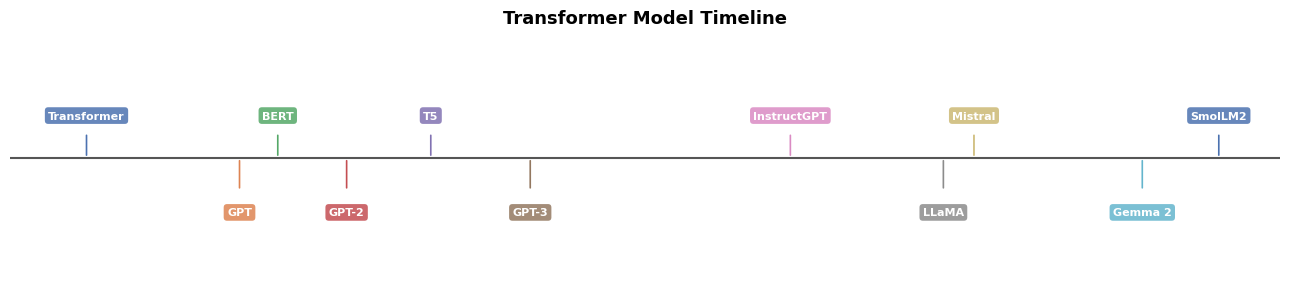

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

models = [
    (2017.5, "Transformer"),
    (2018.5, "GPT"),
    (2018.75, "BERT"),
    (2019.2, "GPT-2"),
    (2019.75, "T5"),
    (2020.4, "GPT-3"),
    (2022.1, "InstructGPT"),
    (2023.1, "LLaMA"),
    (2023.3, "Mistral"),
    (2024.4, "Gemma 2"),
    (2024.9, "SmolLM2"),
]

fig, ax = plt.subplots(figsize=(13, 3))
ax.axhline(0, color="#555", linewidth=1.5, zorder=0)

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
          "#8172B2", "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD", "#4C72B0"]

for i, (year, name) in enumerate(models):
    y = 0.35 if i % 2 == 0 else -0.45
    ax.annotate("", xy=(year, 0), xytext=(year, y * 0.6),
                arrowprops=dict(arrowstyle="-", color=colors[i], lw=1.2))
    ax.text(year, y, name, ha="center", va="center", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc=colors[i], ec="none", alpha=0.85),
            color="white", fontweight="bold")

ax.set_xlim(2017, 2025.3)
ax.set_ylim(-1, 1)
ax.axis("off")
ax.set_title("Transformer Model Timeline", fontsize=13, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()

### General Transformer Architecture

The Transformer has two main blocks:

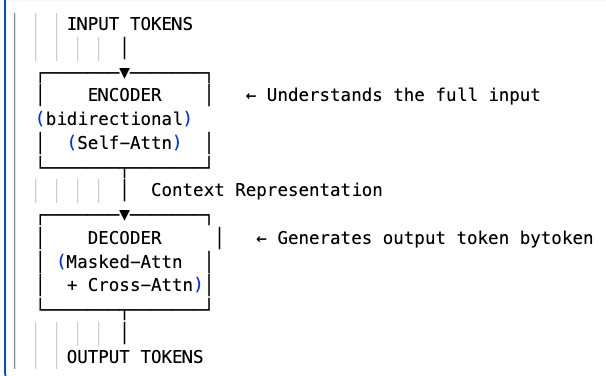


Each block can be used **independently**:

| Architecture | Block(s) Used | Best For | Examples |
|---|---|---|---|
| Encoder-only | Encoder | Classification, NER, Q&A | BERT, RoBERTa, DistilBERT |
| Decoder-only | Decoder | Text generation | GPT-2, LLaMA, Mistral |
| Encoder-Decoder | Both | Translation, Summarization | T5, BART, mBART |

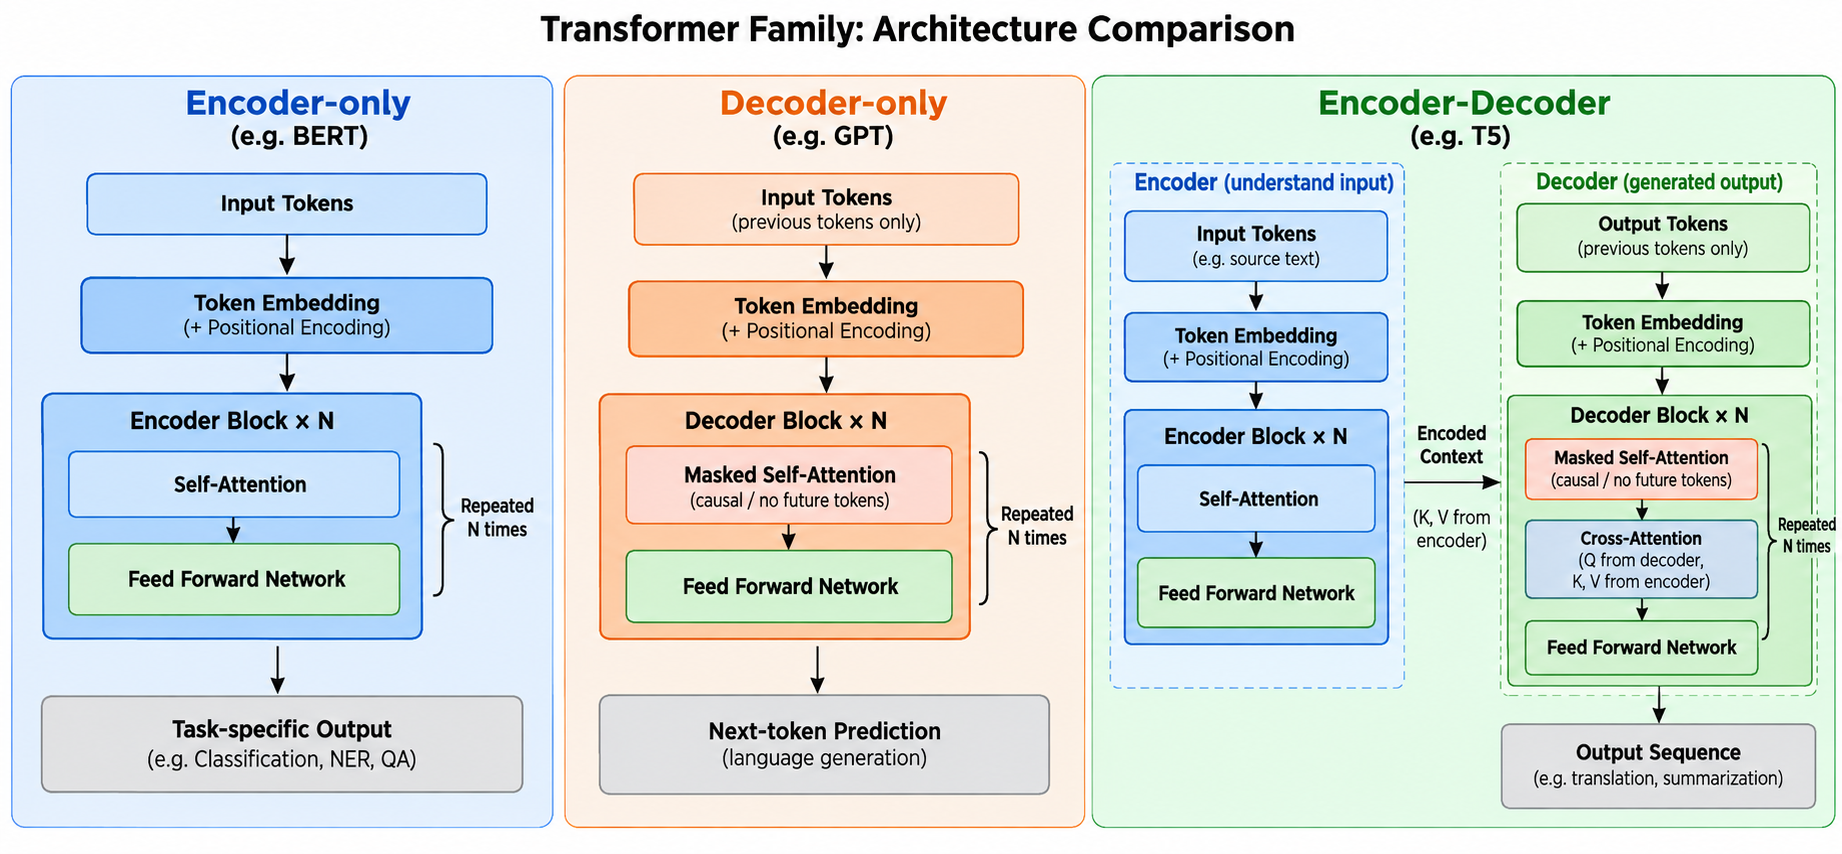



### 1. Encoder-only — BERT

**Flow:** Input Tokens → Token Embedding → Encoder Blocks × N → Task-specific Output

An **Encoder Block** contains **Self-Attention + Feed Forward Network**.

Self-Attention allows every token to look at the other tokens in the input sequence, including tokens that appear before and after it. Therefore, the encoder can understand the input using information from the **entire sequence**.

For example, in the sentence **"The cat sat on the mat"**, when processing "cat", the encoder can use information from both "The" before it and "sat on the mat" after it.

**Typical applications:** Classification, Sentiment Analysis, Named Entity Recognition (NER), Extractive Question Answering, Semantic Similarity.

**Mental model:** BERT = **Understand the input**

---

### 2. Decoder-only — GPT

**Flow:** Input Tokens → Token Embedding → Decoder Blocks × N → Next-token Prediction

A GPT-style **Decoder Block** contains **Masked Self-Attention + Feed Forward Network**.

The word **"masked"** is important because GPT generates text from left to right. When predicting the next token, the model can see the current and previous tokens but **cannot see future tokens**.

For example:

"The" → predict "cat"

"The cat" → predict "sat"

"The cat sat" → predict the next token

This is called **causal or autoregressive generation**.

**Typical applications:** Text Generation, Chatbots, Code Generation, Story Generation, and Language Modeling.

**Mental model:** GPT = **Predict the next token**

### Why is GPT called "Decoder-only"?

The original Transformer decoder contains:

**Masked Self-Attention → Cross-Attention → Feed Forward**

GPT does not have an encoder, so there is no encoder output to attend to. Therefore, GPT uses the **masked self-attention + feed-forward structure** but does not use encoder-decoder cross-attention.

So:

**GPT = Decoder-style blocks without Cross-Attention**

---

### 3. Encoder-Decoder — T5

The Encoder-Decoder architecture contains two parts:

**Encoder → Encoded Context → Decoder → Output Sequence**

This architecture is useful when we want to **transform one sequence into another**.

Examples:

**English text → French translation**

**Long document → Summary**

**Input text → Output text**

### Encoder

**Flow:** Input → Token Embedding → Encoder Blocks × N → Encoded Context

Each Encoder Block contains:

**Self-Attention → Feed Forward Network**

The encoder processes the complete input sequence and creates a contextual representation called the **Encoded Context**.

The encoder can look at the entire input sequence because its self-attention is not causally masked.

### Decoder

**Flow:** Output Tokens → Token Embedding → Decoder Blocks × N → Output Sequence

Each Decoder Block contains:

**Masked Self-Attention → Cross-Attention → Feed Forward Network**

The decoder generates the output sequence one token at a time.

---

### 4. What is Cross-Attention?

**Cross-Attention connects the Decoder to the Encoder.**

The important relationship is:

**Q ← Decoder**

**K ← Encoder**

**V ← Encoder**


                 ENCODER
                    │
              "I love cats"
                    │
                    ↓
             Encoded Context
                    │
              ┌─────┴─────┐
              ↓           ↓
              K           V
              │           │
              └─────┬─────┘
                    │
                    ↓
              CROSS-ATTENTION
                    ↑
                    │
                    Q
                    │
                 DECODER
                    │
              "What should
               I focus on?"

               
In other words, the decoder creates the **Query (Q)**, while the encoder provides the **Keys (K)** and **Values (V)**.

Conceptually:

**Encoder → Encoded Context → K, V → Cross-Attention**

**Decoder → Q → Cross-Attention**

Cross-Attention allows the decoder to ask:

> **"Which parts of the input should I pay attention to while generating this output token?"**

This is what allows the decoder to use the information that was learned by the encoder.

---

### 5. Example: Machine Translation

Suppose the input is:

**"I love cats."**

### Encoder

The encoder processes the complete source sentence:

**"I love cats." → Encoder → Encoded Context**

The encoder creates contextual representations of the entire source sentence.

### Decoder

The decoder generates the target sentence step by step:

**<START> → "J'" → "J'aime" → "J'aime les" → "J'aime les chats"**

At every generation step:

- **Masked Self-Attention** looks at previously generated output tokens.
- **Cross-Attention** looks at the encoder's representation of the source sentence.
- **Feed Forward Network** further processes the representation.

Therefore, T5 performs:

**Understand the input → Use the encoded context → Generate the output**

---

### 6. The Three Architectures Compared

| Feature | Encoder-only | Decoder-only | Encoder-Decoder |
|---|---|---|---|
| Example | BERT | GPT | T5 |
| Main purpose | Understand input | Generate text | Transform input → output |
| Self-Attention | Yes | Masked | Encoder: Yes |
| Masked Self-Attention | No | Yes | Decoder: Yes |
| Cross-Attention | No | No | Yes |
| Feed Forward Network | Yes | Yes | Yes |
| Typical output | Task-specific output | Next-token prediction | Output sequence |
| Typical tasks | Classification, NER, QA | Chat, code, text generation | Translation, summarization |

---

### 7. The Simplest Way to Remember

### BERT — Encoder-only

**Input → Encoder → Representation → Task**

**Think: UNDERSTAND**

### GPT — Decoder-only

**Previous Tokens → Decoder → Next Token**

**Think: GENERATE**

### T5 — Encoder-Decoder

**Input → Encoder → Encoded Context → Decoder → Output**

**Think: TRANSFORM**

---

### 8. Why the Three Architectures Are Different

The important thing is not that they are completely different types of neural networks. They are built from the same fundamental Transformer ideas.

The difference is **how the blocks are arranged and how attention is allowed to flow**.

**Encoder Block:**

Self-Attention → Feed Forward Network

**Decoder Block:**

Masked Self-Attention → Cross-Attention → Feed Forward Network

Then:

**BERT = Encoder Blocks × N**

**GPT = Decoder-style Blocks × N, without Cross-Attention**

**T5 = Encoder Blocks × N + Decoder Blocks × N**

---

### 9. Final Takeaway

The entire Transformer family can be remembered with three words:

**BERT → Understand**

**GPT → Generate**

**T5 → Transform**

The key architectural distinction is:

**BERT:** The encoder sees the entire input.

**GPT:** The decoder generates the next token using only previous/current tokens.

**T5:** The encoder understands the input, and the decoder generates the output while using **Cross-Attention** to access the encoder's information.

> **Same Transformer foundation, different information flow.**

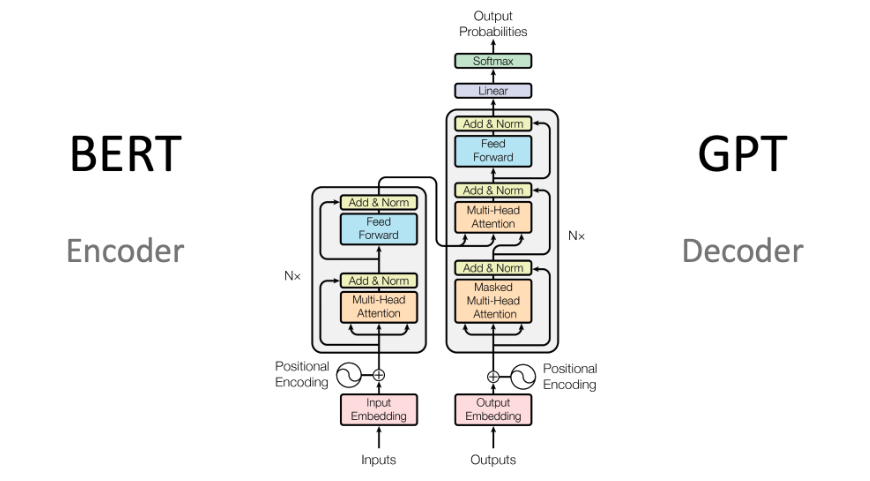

### The Attention Mechanism

Attention layers allow the model to **focus on relevant words** when processing each word in a sequence.

> **Example:** Translating *"You like this course"* to French.
> - To translate *"like"* → must attend to *"You"* (verb conjugation depends on subject)
> - To translate *"this"* → must attend to *"course"* (masculine/feminine agreement)

**Three types of attention in the full Transformer:**

| Attention Type | Where Used | Direction | Purpose |
|---|---|---|---|
| **Self-Attention** | Encoder | Bidirectional (all ↔ all) | Each token attends to all input tokens |
| **Masked Self-Attention** | Decoder | Unidirectional (left only) | Each token attends only to past tokens |
| **Cross-Attention** | Decoder | Decoder → Encoder output | Decoder uses full encoder context |

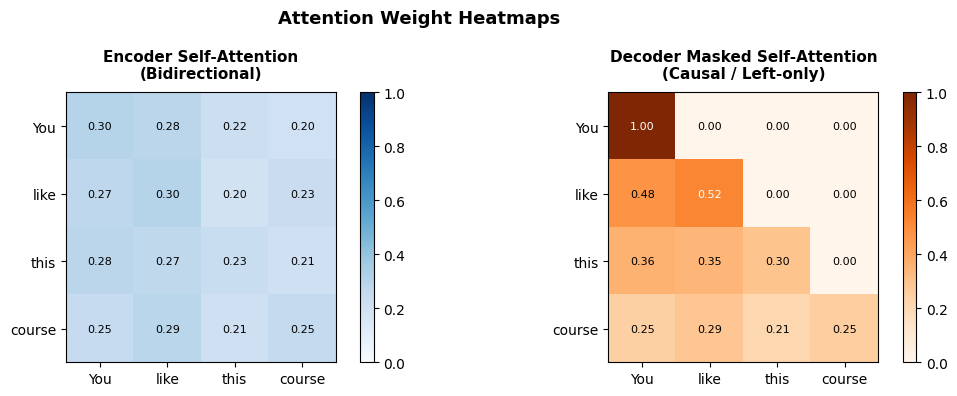

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights

tokens = ["You", "like", "this", "course"]
n = len(tokens)

torch.manual_seed(42)
Q = torch.rand(1, n, 8)
K = torch.rand(1, n, 8)
V = torch.rand(1, n, 8)

# Encoder: bidirectional (no mask)
_, enc_weights = scaled_dot_product_attention(Q, K, V)

# Decoder: masked (causal)
causal_mask = torch.tril(torch.ones(n, n)).unsqueeze(0)
_, dec_weights = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, weights, title, cmap in zip(
    axes,
    [enc_weights.squeeze().detach(), dec_weights.squeeze().detach()],
    ["Encoder Self-Attention\n(Bidirectional)", "Decoder Masked Self-Attention\n(Causal / Left-only)"],
    ["Blues", "Oranges"]
):
    im = ax.imshow(weights.numpy(), cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(tokens, fontsize=10)
    ax.set_yticklabels(tokens, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    for i in range(n):
        for j in range(n):
            val = weights[i, j].item()
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if val > 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Attention Weight Heatmaps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### The Original Transformer Architecture

Originally designed for **machine translation** (English → French, etc.).

**During training:**
- The **encoder** receives the full source sentence and builds a context representation
- The **decoder** receives the target sentence *shifted right* but uses a **causal mask** to prevent attending to future tokens


**Two attention layers inside each Decoder block:**
1. **Masked Self-Attention** — attends to previous *decoder* outputs only
2. **Cross-Attention** — attends to the *full encoder output* (so it can use source context)

> The **attention mask** can also hide padding tokens — ensuring the model doesn't waste attention on `[PAD]` tokens added to equalize batch lengths.


In [ ]:
# Encoder-Decoder in action: the SAME French->English translation model we tried in the pipeline
# tour above, called directly through its tokenizer + model (no pipeline() wrapper this time) so the
# encode -> generate -> decode steps are all visible.
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

mt_tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-fr-en")
mt_model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-fr-en")

french_text = "L'intelligence artificielle change le monde."
mt_inputs = mt_tokenizer(french_text, return_tensors="pt")
mt_generated = mt_model.generate(**mt_inputs)
print(f"FR: {french_text}")
print(f"EN: {mt_tokenizer.decode(mt_generated[0], skip_special_tokens=True)}")

# For contrast: an ENCODER-ONLY model on the same kind of input -- it can only fill in a blank,
# it has no decoder to generate a full free-form sequence with.
print("\n=== Encoder-only: Masked Language Model ===")
mask_filler_bert = pipeline("fill-mask", model="bert-base-uncased")
masked_sentence = "The [MASK] mechanism is key to Transformer models."
print(f"Input: {masked_sentence}\n")
for pred in mask_filler_bert(masked_sentence)[:3]:
    print(f"  -> '{pred['token_str']}' (score: {pred['score']:.3f})")


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

FR: L'intelligence artificielle change le monde.
EN: Artificial intelligence is changing the world.

=== Encoder-only: Masked Language Model ===


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Input: The [MASK] mechanism is key to Transformer models.

  -> 'control' (score: 0.038)
  -> 'coupling' (score: 0.034)
  -> 'feedback' (score: 0.017)


### Architecture vs. Checkpoint vs. Model

These three terms are often used interchangeably but have distinct meanings:

| Term | Meaning | Example |
|------|---------|---------|
| **Architecture** | The model's skeleton — layers, operations, dimensions | BERT (the design) |
| **Checkpoint** | Trained weights loaded into an architecture | `bert-base-cased` (Google's weights) |
| **Model** | Umbrella term — can refer to either | "the BERT model" |

> 💡 You can say *"the BERT model"* casually, but when precision matters, say *"the bert-base-cased checkpoint"* to specify exactly which weights.

In [ ]:
from transformers import AutoModel, AutoTokenizer

# Same architecture (BERT), different checkpoints → different behavior
checkpoints = [
    "bert-base-uncased",   # lowercase, general English
    "bert-base-multilingual-cased",  # 104 languages
]

print("=== Same Architecture, Different Checkpoints ===\n")
for ckpt in checkpoints:
    tokenizer = AutoTokenizer.from_pretrained(ckpt)
    model = AutoModel.from_pretrained(ckpt)
    params = sum(p.numel() for p in model.parameters()) / 1e6
    vocab = tokenizer.vocab_size
    print(f"Checkpoint : {ckpt}")
    print(f"  Params   : {params:.1f}M")
    print(f"  Vocab    : {vocab:,} tokens")
    print(f"  Architecture: {model.__class__.__name__}\n")

=== Same Architecture, Different Checkpoints ===



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint : bert-base-uncased
  Params   : 109.5M
  Vocab    : 30,522 tokens
  Architecture: BertModel



config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint : bert-base-multilingual-cased
  Params   : 177.9M
  Vocab    : 119,547 tokens
  Architecture: BertModel



## ATTENTION

### What Is Attention?

Before Transformers, RNNs processed sequences **one token at a time** — making it hard to connect words far apart in a sentence. Attention solves this by letting every token look at **every other token simultaneously**.

**Core Idea:**  
> *"How relevant is word X to understanding word Y?"*

Attention computes a **weighted sum** of all values, where the weights represent how much each token should "attend" to every other token.

**The three ingredients — Q, K, V:**

| Symbol | Full Name | Role | Analogy |
|--------|-----------|------|---------|
| **Q** | Query | What am I looking for? | Search query |
| **K** | Key | What do I contain? | Search index |
| **V** | Value | What do I return? | Search result |

**The formula:**

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Steps:
1. Compute **similarity scores**: `Q · Kᵀ` — how much does each query match each key?
2. **Scale** by `√d_k` — prevents scores from exploding with large dimensions
3. Apply **softmax** — converts scores to probabilities (attention weights)
4. **Weighted sum** of V — blend values based on attention weights

STEP 1: Compute raw scores — Q · Kᵀ
Scores shape: (5, 5)
[[-1.37 -0.46  2.17 -1.19 -0.19]
 [-1.28 -1.43  0.68  0.61 -1.54]
 [-0.18  0.67 -0.46 -0.38 -0.64]
 [ 1.47  1.43  0.41  1.29  5.98]
 [ 0.4   1.1  -1.55  0.66  0.1 ]]

STEP 2: Scale by √d_k = √4 = 2.00
[[-0.68 -0.23  1.09 -0.59 -0.09]
 [-0.64 -0.71  0.34  0.31 -0.77]
 [-0.09  0.34 -0.23 -0.19 -0.32]
 [ 0.74  0.72  0.2   0.64  2.99]
 [ 0.2   0.55 -0.78  0.33  0.05]]

STEP 3: Softmax → Attention Weights
Each row sums to 1.0:
[[0.088 0.139 0.518 0.096 0.159]
 [0.124 0.115 0.331 0.32  0.109]
 [0.196 0.3   0.17  0.177 0.156]
 [0.077 0.075 0.045 0.07  0.733]
 [0.208 0.296 0.079 0.237 0.18 ]]
Row sums: [1. 1. 1. 1. 1.]

STEP 4: Weighted sum of V → Output
Output shape: (5, 4)
[[-0.161 -0.987  0.246  0.166]
 [-0.273 -0.483  0.406  0.362]
 [-0.492 -0.423  0.129  0.51 ]
 [-0.701 -0.304  0.286  0.819]
 [-0.569 -0.226  0.169  0.617]]


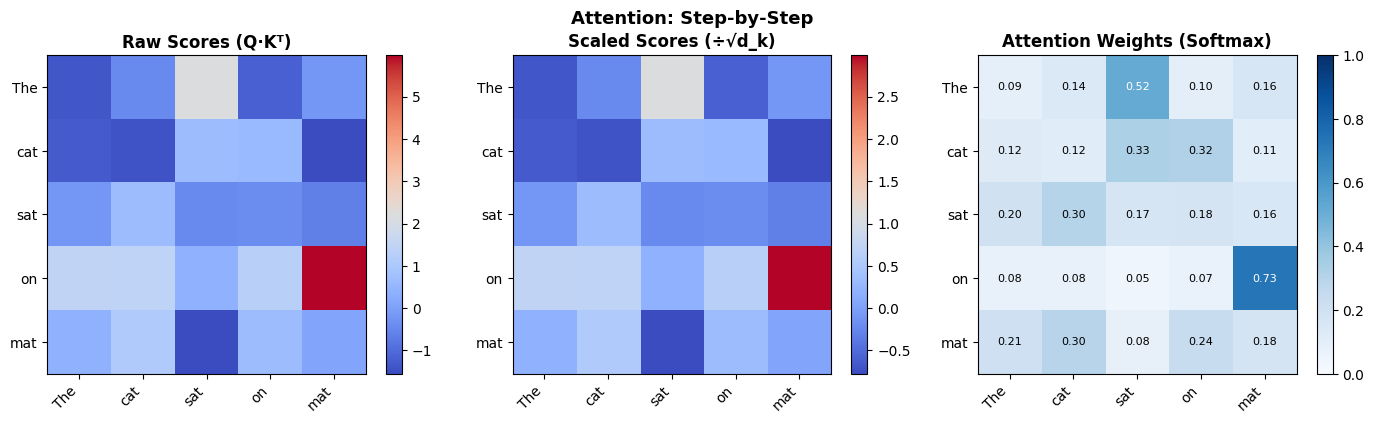

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Step-by-step Attention from Scratch (NumPy) ──

np.random.seed(42)
d_k = 4  # key/query dimension
d_v = 4  # value dimension
seq_len = 5

tokens = ["The", "cat", "sat", "on", "mat"]

# Randomly initialized Q, K, V (normally learned via linear layers)
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_v)

print("=" * 50)
print("STEP 1: Compute raw scores — Q · Kᵀ")
print("=" * 50)
scores = Q @ K.T          # shape: (seq_len, seq_len)
print(f"Scores shape: {scores.shape}")
print(np.round(scores, 2))

print("\n" + "=" * 50)
print(f"STEP 2: Scale by √d_k = √{d_k} = {np.sqrt(d_k):.2f}")
print("=" * 50)
scores_scaled = scores / np.sqrt(d_k)
print(np.round(scores_scaled, 2))

print("\n" + "=" * 50)
print("STEP 3: Softmax → Attention Weights")
print("=" * 50)
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))  # numerically stable
    return e / e.sum(axis=-1, keepdims=True)

attn_weights = softmax(scores_scaled)   # shape: (seq_len, seq_len)
print("Each row sums to 1.0:")
print(np.round(attn_weights, 3))
print("Row sums:", np.round(attn_weights.sum(axis=-1), 3))

print("\n" + "=" * 50)
print("STEP 4: Weighted sum of V → Output")
print("=" * 50)
output = attn_weights @ V              # shape: (seq_len, d_v)
print(f"Output shape: {output.shape}")
print(np.round(output, 3))

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(scores, cmap="coolwarm")
axes[0].set_title("Raw Scores (Q·Kᵀ)", fontweight="bold")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(scores_scaled, cmap="coolwarm")
axes[1].set_title("Scaled Scores (÷√d_k)", fontweight="bold")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(attn_weights, cmap="Blues", vmin=0, vmax=1)
axes[2].set_title("Attention Weights (Softmax)", fontweight="bold")
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xticks(range(seq_len)); ax.set_yticks(range(seq_len))
    ax.set_xticklabels(tokens, rotation=45, ha="right")
    ax.set_yticklabels(tokens)

for i in range(seq_len):
    for j in range(seq_len):
        axes[2].text(j, i, f"{attn_weights[i,j]:.2f}",
                     ha="center", va="center", fontsize=8,
                     color="white" if attn_weights[i,j] > 0.35 else "black")

plt.suptitle("Attention: Step-by-Step", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Self-Attention

In **self-attention**, Q, K, and V all come from the **same sequence** — the sequence attends to itself. This lets every token build a rich contextual representation by looking at all other tokens.

**How Q, K, V are created from the input:**
Input Embedding (X)
│<br>
├──× Wq ──→ Q (Query matrix)<br>
├──× Wk ──→ K (Key matrix)<br>
└──× Wv ──→ V (Value matrix)<br>
<br>


`Wq`, `Wk`, `Wv` are **learned weight matrices** (trained via backprop).

<br>
**Multi-Head Attention:**  
Instead of running one attention, Transformers run `h` parallel attention heads, each learning different relationship patterns:

<br>
Input X
│<br>
├─ Head 1: [Q₁K₁V₁] → output₁ (e.g. syntactic relations)<br>
├─ Head 2: [Q₂K₂V₂] → output₂ (e.g. coreference)<br>
├─ ...<br>
└─ Head h: [QₕKₕVₕ] → outputₕ (e.g. positional patterns)<br>
│<br>
Concatenate → × Wo → Final Output<br>

Each head sees the **same input** but through different projection matrices — they specialize in different types of relationships.

Input shape:  torch.Size([1, 6, 16])        → (batch, tokens, embed_dim)
Output shape: torch.Size([1, 6, 16])      → same shape as input
Attn weights: torch.Size([1, 2, 6, 6])  → (batch, heads, tokens, tokens)


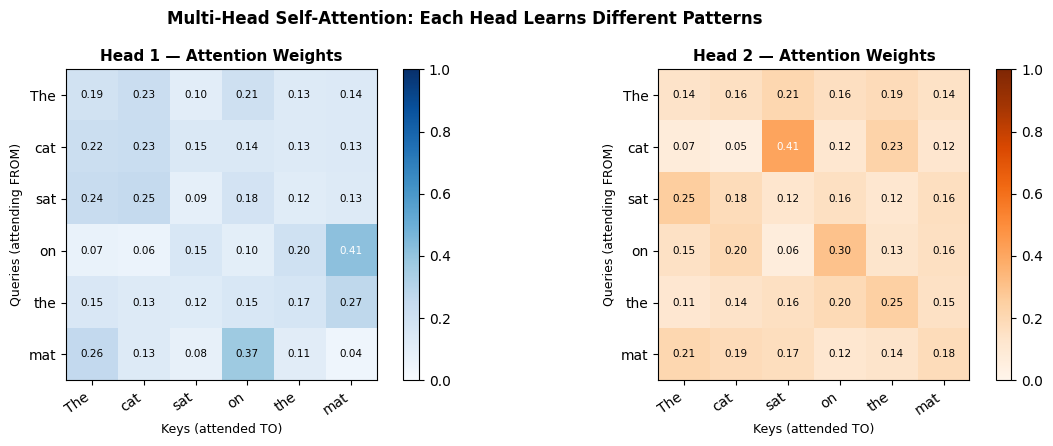


=== 'cat' attends to (Head 1) ===
  The   : 0.220
  cat   : 0.233
  sat   : 0.146
  on    : 0.142
  the   : 0.126
  mat   : 0.133


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Full Self-Attention Module ──

class SelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads

        self.Wq = nn.Linear(embed_dim, embed_dim, bias=False)
        self.Wk = nn.Linear(embed_dim, embed_dim, bias=False)
        self.Wv = nn.Linear(embed_dim, embed_dim, bias=False)
        self.Wo = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, x):
        B, T, E = x.shape
        H, D = self.num_heads, self.head_dim

        Q = self.Wq(x).view(B, T, H, D).transpose(1, 2)  # (B, H, T, D)
        K = self.Wk(x).view(B, T, H, D).transpose(1, 2)
        V = self.Wv(x).view(B, T, H, D).transpose(1, 2)

        scores  = torch.matmul(Q, K.transpose(-2, -1)) / (D ** 0.5)
        weights = F.softmax(scores, dim=-1)               # (B, H, T, T)

        out = torch.matmul(weights, V)                    # (B, H, T, D)
        out = out.transpose(1, 2).contiguous().view(B, T, E)
        return self.Wo(out), weights

# ── Demo ──
torch.manual_seed(7)
sentence = ["The", "cat", "sat", "on", "the", "mat"]
T = len(sentence)
embed_dim = 16
num_heads = 2

x = torch.randn(1, T, embed_dim)
attn = SelfAttention(embed_dim, num_heads)
out, weights = attn(x)

print(f"Input shape:  {x.shape}        → (batch, tokens, embed_dim)")
print(f"Output shape: {out.shape}      → same shape as input")
print(f"Attn weights: {weights.shape}  → (batch, heads, tokens, tokens)")

# ── Visualize each head ──
fig, axes = plt.subplots(1, num_heads, figsize=(12, 4.5))
head_colors = ["Blues", "Oranges"]

for h in range(num_heads):
    w = weights[0, h].detach().numpy()
    im = axes[h].imshow(w, cmap=head_colors[h], vmin=0, vmax=1)
    axes[h].set_title(f"Head {h+1} — Attention Weights", fontsize=11, fontweight="bold")
    axes[h].set_xticks(range(T)); axes[h].set_yticks(range(T))
    axes[h].set_xticklabels(sentence, rotation=35, ha="right", fontsize=10)
    axes[h].set_yticklabels(sentence, fontsize=10)
    axes[h].set_xlabel("Keys (attended TO)", fontsize=9)
    axes[h].set_ylabel("Queries (attending FROM)", fontsize=9)
    for i in range(T):
        for j in range(T):
            axes[h].text(j, i, f"{w[i,j]:.2f}", ha="center", va="center",
                         fontsize=7.5, color="white" if w[i,j] > 0.4 else "black")
    plt.colorbar(im, ax=axes[h], fraction=0.046)

plt.suptitle("Multi-Head Self-Attention: Each Head Learns Different Patterns",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Compare: what does position 1 ("cat") attend to? ──
print("\n=== 'cat' attends to (Head 1) ===")
for i, tok in enumerate(sentence):
    print(f"  {tok:6s}: {weights[0, 0, 1, i].item():.3f}")

### Visualizing Attention in a Real, Already-Pretrained Model

The toy demos above use random Q/K/V weights purely to show the mechanism. Now let's look at attention
patterns a real transformer actually **learned** during pretraining.

In [ ]:
# Load DistilBERT with output_attentions=True so it returns its internal attention weight matrices.
# Self-contained on purpose: its own tokenizer + model, so it does not depend on whichever
# tokenizer/model happened to be loaded last in an earlier section.
from transformers import AutoTokenizer, AutoModel

real_attn_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
real_attn_model = AutoModel.from_pretrained("distilbert-base-uncased", output_attentions=True)
real_attn_model.eval()

sentence = "The animal did not cross the street because it was tired"
inputs = real_attn_tokenizer(sentence, return_tensors="pt")

with torch.no_grad():
    outputs = real_attn_model(**inputs)

# outputs.attentions: one entry per layer (6 layers in DistilBERT), each (batch=1, heads=12, seq_len, seq_len)
print(f"Number of layers with attention returned: {len(outputs.attentions)}")
print(f"Shape of one layer's attention tensor:     {outputs.attentions[0].shape}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of layers with attention returned: 6
Shape of one layer's attention tensor:     torch.Size([1, 12, 13, 13])


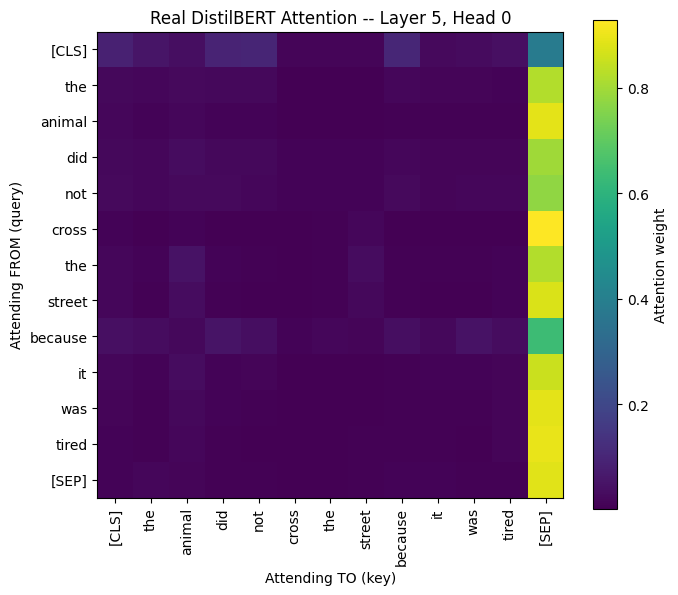

In [ ]:
# Pick one layer/head to visualize (change these indices and re-run to explore others).
layer_idx, head_idx = 5, 0   # last layer, first head

attention_matrix = outputs.attentions[layer_idx][0, head_idx].detach().numpy()
token_labels = real_attn_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

plt.figure(figsize=(7, 6))
plt.imshow(attention_matrix, cmap="viridis")
plt.xticks(range(len(token_labels)), token_labels, rotation=90)
plt.yticks(range(len(token_labels)), token_labels)
plt.xlabel("Attending TO (key)")
plt.ylabel("Attending FROM (query)")
plt.title(f"Real DistilBERT Attention -- Layer {layer_idx}, Head {head_idx}")
plt.colorbar(label="Attention weight")
plt.tight_layout()
plt.show()
# Look at the row for "it" -- in well-trained heads, it often lights up strongly over "animal",
# exactly the kind of long-range coreference link attention was built to capture.


POSITIONAL ENCODING, TOKENIZATION, EMBEDDINGS ### Tokenization

Transformers can't read raw text — they need **tokens** (integer IDs). Tokenization converts text into a sequence of token IDs.

**Common strategies:**

| Strategy | How It Works | Example |
|---|---|---|
| **Word-level** | Split on whitespace | `"playing"` → `[playing]` |
| **Character-level** | Split into characters | `"cat"` → `[c, a, t]` |
| **BPE / WordPiece** | Merge frequent subword pairs | `"playing"` → `[play, ##ing]` |
| **SentencePiece** | Language-agnostic subword | `"playing"` → `[▁play, ing]` |

Modern LLMs use **BPE (Byte-Pair Encoding)** or **WordPiece** — they handle rare words by breaking them into known subwords, so the vocabulary stays manageable (~30K–50K tokens).

In [ ]:
from transformers import AutoTokenizer

# Three tokenizers — same sentence, different strategies
sentence = "The Transformer architecture revolutionized NLP!"

tokenizers = {
    "BERT (WordPiece)":       "bert-base-uncased",
    "GPT-2 (BPE)":            "gpt2",
    "T5 (SentencePiece)":     "t5-small",
}

print(f"Original: '{sentence}'\n")
print("=" * 60)

for name, ckpt in tokenizers.items():
    tok = AutoTokenizer.from_pretrained(ckpt)
    ids = tok.encode(sentence)
    tokens = tok.convert_ids_to_tokens(ids)
    print(f"\n{name}")
    print(f"  Tokens : {tokens}")
    print(f"  IDs    : {ids}")
    print(f"  Count  : {len(ids)} tokens")

# ── Subword handling: rare / unknown word ──
print("\n" + "=" * 60)
print("Subword handling — rare word 'Supercalifragilistic'")
bert_tok = AutoTokenizer.from_pretrained("bert-base-uncased")
rare = "Supercalifragilistic"
print(f"  BERT tokens: {bert_tok.tokenize(rare)}")

gpt2_tok = AutoTokenizer.from_pretrained("gpt2")
print(f"  GPT-2 tokens: {gpt2_tok.tokenize(rare)}")

Original: 'The Transformer architecture revolutionized NLP!'


BERT (WordPiece)
  Tokens : ['[CLS]', 'the', 'transform', '##er', 'architecture', 'revolution', '##ized', 'nl', '##p', '!', '[SEP]']
  IDs    : [101, 1996, 10938, 2121, 4294, 4329, 3550, 17953, 2361, 999, 102]
  Count  : 11 tokens


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]


GPT-2 (BPE)
  Tokens : ['The', 'ĠTrans', 'former', 'Ġarchitecture', 'Ġrevolution', 'ized', 'ĠN', 'LP', '!']
  IDs    : [464, 3602, 16354, 10959, 5854, 1143, 399, 19930, 0]
  Count  : 9 tokens

T5 (SentencePiece)
  Tokens : ['▁The', '▁Transformer', '▁architecture', '▁revolution', 'ized', '▁N', 'LP', '!', '</s>']
  IDs    : [37, 31220, 4648, 9481, 1601, 445, 6892, 55, 1]
  Count  : 9 tokens

Subword handling — rare word 'Supercalifragilistic'
  BERT tokens: ['super', '##cal', '##if', '##rag', '##ilis', '##tic']
  GPT-2 tokens: ['Super', 'cal', 'if', 'rag', 'il', 'istic']


### Embeddings

After tokenization, each token ID is mapped to a **dense vector** (embedding) in a high-dimensional space.

Token ID → [Embedding Table] → Dense Vector (d_model dimensions)
234 → E[234] → [0.12, -0.87, 0.44, ..., 0.03] ← 768 values for BERT


**Key properties of embeddings:**
- Learned during training — similar words end up close together
- Capture **semantic** meaning: king − man + woman ≈ queen
- Shape: `(vocab_size, d_model)` — BERT has `(30,522 × 768)` ≈ 23M parameters just in embeddings

**Why not one-hot vectors?**  
One-hot vectors are huge (vocab_size) and sparse. Embeddings are compact (d_model << vocab_size) and dense — much more efficient and expressive.



=== Manual Embedding Lookup ===
Token IDs  : [2, 5, 7]
Embedded shape: torch.Size([3, 6])  → (3 tokens × 6 dims)
[[-0.134  0.638  0.616 -1.14   0.603 -1.178]
 [-1.703  0.167 -0.804  0.824  0.301 -0.881]
 [ 1.199  0.197  0.02  -0.171 -1.995 -0.333]]

=== Real BERT Embeddings: Semantic Similarity ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


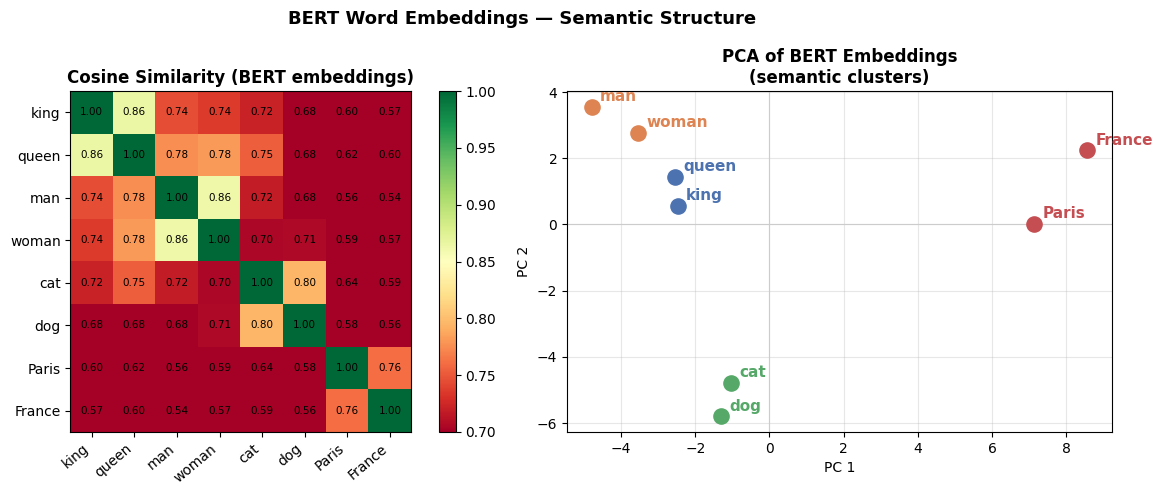

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModel

# ── Part 1: Manual embedding lookup ──
vocab_size = 10
d_model    = 6
embedding_table = nn.Embedding(vocab_size, d_model)

token_ids = torch.tensor([2, 5, 7])
embedded  = embedding_table(token_ids)

print("=== Manual Embedding Lookup ===")
print(f"Token IDs  : {token_ids.tolist()}")
print(f"Embedded shape: {embedded.shape}  → (3 tokens × {d_model} dims)")
print(np.round(embedded.detach().numpy(), 3))

# ── Part 2: Real BERT embeddings — semantic similarity ──
print("\n=== Real BERT Embeddings: Semantic Similarity ===")
from sklearn.metrics.pairwise import cosine_similarity

tok   = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")
model.eval()

words = ["king", "queen", "man", "woman", "cat", "dog", "Paris", "France"]

embeddings = []
with torch.no_grad():
    for word in words:
        ids  = tok(word, return_tensors="pt")
        out  = model(**ids).last_hidden_state[0, 1, :]  # [CLS] → token
        embeddings.append(out.numpy())

emb_matrix = np.array(embeddings)
sim = cosine_similarity(emb_matrix)

# ── PCA plot ──
pca  = PCA(n_components=2)
xy   = pca.fit_transform(emb_matrix)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cosine similarity heatmap
im = axes[0].imshow(sim, cmap="RdYlGn", vmin=0.7, vmax=1.0)
axes[0].set_xticks(range(len(words))); axes[0].set_yticks(range(len(words)))
axes[0].set_xticklabels(words, rotation=40, ha="right", fontsize=10)
axes[0].set_yticklabels(words, fontsize=10)
axes[0].set_title("Cosine Similarity (BERT embeddings)", fontweight="bold")
plt.colorbar(im, ax=axes[0], fraction=0.046)
for i in range(len(words)):
    for j in range(len(words)):
        axes[0].text(j, i, f"{sim[i,j]:.2f}", ha="center", va="center", fontsize=7.5)

# PCA scatter
colors = ["#4C72B0","#4C72B0","#DD8452","#DD8452","#55A868","#55A868","#C44E52","#C44E52"]
for i, (x, y) in enumerate(xy):
    axes[1].scatter(x, y, color=colors[i], s=120, zorder=3)
    axes[1].annotate(words[i], (x, y), textcoords="offset points",
                     xytext=(6, 4), fontsize=11, fontweight="bold", color=colors[i])
axes[1].set_title("PCA of BERT Embeddings\n(semantic clusters)", fontweight="bold")
axes[1].axhline(0, color="#ccc", lw=0.8); axes[1].axvline(0, color="#ccc", lw=0.8)
axes[1].set_xlabel("PC 1"); axes[1].set_ylabel("PC 2")
axes[1].grid(True, alpha=0.3)

plt.suptitle("BERT Word Embeddings — Semantic Structure", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Positional Encoding

Self-attention is **permutation-invariant** — it treats the input as a set, not a sequence. Swapping all words gives the same attention weights. So the model has no idea about word **order**.

**Fix:** Add **positional encodings** to the embeddings before feeding into the Transformer.


Final Input = Token Embedding + Positional Encoding


**Sinusoidal Positional Encoding (original paper):**

$$PE_{(pos, 2i)}   = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

- `pos` = position in the sequence
- `i` = dimension index
- Uses sin for even dimensions, cos for odd dimensions
- **No learned parameters** — purely mathematical

**Why sinusoidal?**
- Different frequencies at different dimensions → each position gets a unique fingerprint
- The model can generalize to sequences longer than seen during training
- Relative positions can be inferred from the encoding

**Modern alternative:** Learned positional embeddings (BERT), RoPE (LLaMA), ALiBi (MPT) — but the intuition is the same.

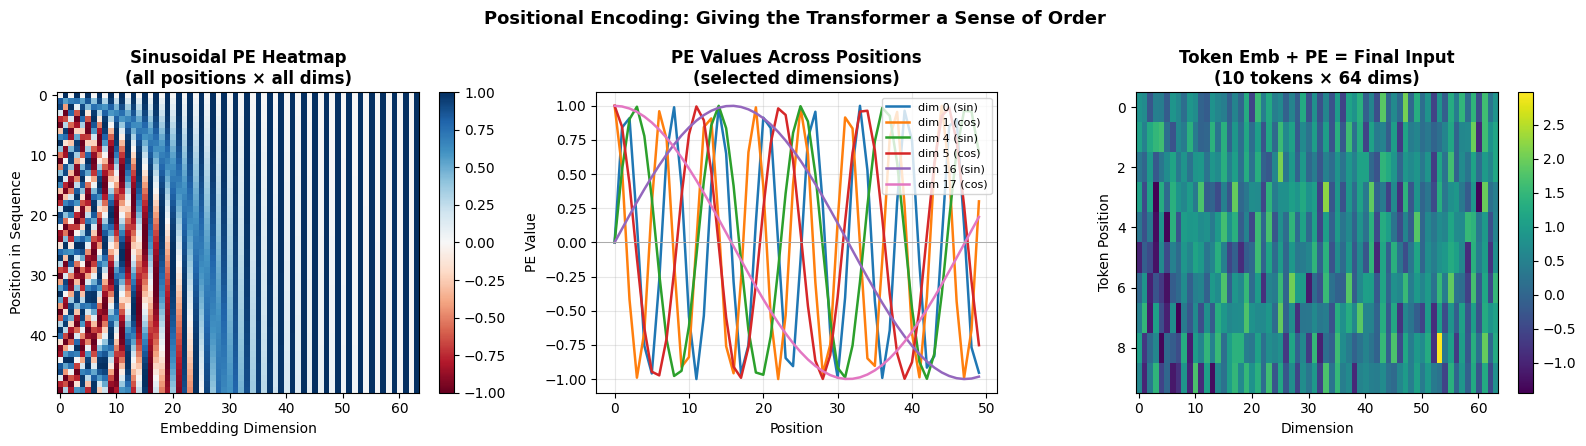

=== Dot-product similarity between positions (should be diagonal-dominant) ===
pos 0 vs pos 0: 32.00  ← same position, max similarity
pos 0 vs pos 1: 30.92  ← adjacent positions, high but < 1
pos 0 vs pos 25: 20.13  ← far apart, lower similarity


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# ── Sinusoidal Positional Encoding ──

def sinusoidal_pe(max_len, d_model):
    PE = np.zeros((max_len, d_model))
    for pos in range(max_len):
        for i in range(0, d_model, 2):
            PE[pos, i]   = np.sin(pos / (10000 ** (i / d_model)))        # even
            if i + 1 < d_model:
                PE[pos, i+1] = np.cos(pos / (10000 ** (i / d_model)))    # odd
    return PE

max_len = 50
d_model = 64
PE = sinusoidal_pe(max_len, d_model)

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Full PE heatmap
im0 = axes[0].imshow(PE, cmap="RdBu", aspect="auto", vmin=-1, vmax=1)
axes[0].set_xlabel("Embedding Dimension", fontsize=10)
axes[0].set_ylabel("Position in Sequence", fontsize=10)
axes[0].set_title("Sinusoidal PE Heatmap\n(all positions × all dims)", fontweight="bold")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Show a few specific dimensions across positions
dims_to_plot = [0, 1, 4, 5, 16, 17]
colors = plt.cm.tab10(np.linspace(0, 0.6, len(dims_to_plot)))
for d, c in zip(dims_to_plot, colors):
    label = f"dim {d} ({'sin' if d%2==0 else 'cos'})"
    axes[1].plot(PE[:, d], label=label, color=c, linewidth=1.8)
axes[1].set_xlabel("Position", fontsize=10)
axes[1].set_ylabel("PE Value", fontsize=10)
axes[1].set_title("PE Values Across Positions\n(selected dimensions)", fontweight="bold")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].axhline(0, color="#aaa", lw=0.7)
axes[1].grid(True, alpha=0.3)

# Token embedding + PE = final input
np.random.seed(1)
tok_emb = np.random.randn(10, d_model) * 0.5    # fake token embeddings
final   = tok_emb + PE[:10, :]                  # add PE

for arr, title, ax in zip(
    [tok_emb, PE[:10, :], final],
    ["Token Embeddings", "+ Positional Encoding", "= Final Input to Transformer"],
    [None, None, axes[2]]
):
    if ax is None: continue
    im2 = ax.imshow(final, cmap="viridis", aspect="auto")
    ax.set_title("Token Emb + PE = Final Input\n(10 tokens × 64 dims)", fontweight="bold")
    ax.set_xlabel("Dimension"); ax.set_ylabel("Token Position")
    plt.colorbar(im2, ax=ax, fraction=0.046)

plt.suptitle("Positional Encoding: Giving the Transformer a Sense of Order",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Sanity check: unique fingerprint per position ──
print("=== Dot-product similarity between positions (should be diagonal-dominant) ===")
sim = PE @ PE.T
print("pos 0 vs pos 0:", f"{sim[0,0]:.2f}  ← same position, max similarity")
print("pos 0 vs pos 1:", f"{sim[0,1]:.2f}  ← adjacent positions, high but < 1")
print("pos 0 vs pos 25:", f"{sim[0,25]:.2f}  ← far apart, lower similarity")

### Practical Implications for Language Understanding and Generation

Putting it all together — tokenization → embeddings → positional encoding → self-attention — creates a model that can:

**For Understanding (Encoder-based, e.g. BERT):**
- Each token's representation is influenced by **all other tokens** (bidirectional context)
- "Bank" in "river bank" vs "bank account" → different representations, same word
- Enables: classification, NER, question answering, semantic search

**For Generation (Decoder-based, e.g. GPT):**
- Each token attends only to **past tokens** (causal / autoregressive)
- Generates token-by-token: the output at step `t` becomes the input at step `t+1`
- Enables: text generation, code generation, chat, summarization

**Context window = memory:**  
The attention mechanism can connect tokens anywhere within the context window. Longer context = more information the model can use, but quadratic memory cost: O(n²) in sequence length.

**Key practical takeaways:**

| Concept | Practical Impact |
|---|---|
| Attention | Model captures long-range dependencies regardless of distance |
| Multi-head | Multiple relationship types learned in parallel |
| Embeddings | Semantic similarity is geometric — enable nearest-neighbour search |
| Positional encoding | Order matters; without it, "dog bites man" = "man bites dog" |
| Context window | Hard limit on how much the model can "see" at once |

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== Contextual Embeddings: "bank" in different sentences ===

  [['[CLS]', 'i', 'went', 'to', 'the', 'river', 'bank', 'to', 'fish', '.', '[SEP]']]
  → Embedding norm: 13.882

  [['[CLS]', 'i', 'deposited', 'money', 'at', 'the', 'bank', '.', '[SEP]']]
  → Embedding norm: 15.734

  [['[CLS]', 'the', 'bank', 'of', 'the', 'river', 'was', 'muddy', '.', '[SEP]']]
  → Embedding norm: 14.182

  [['[CLS]', 'the', 'bank', 'approved', 'my', 'loan', 'application', '.', '[SEP]']]
  → Embedding norm: 15.049



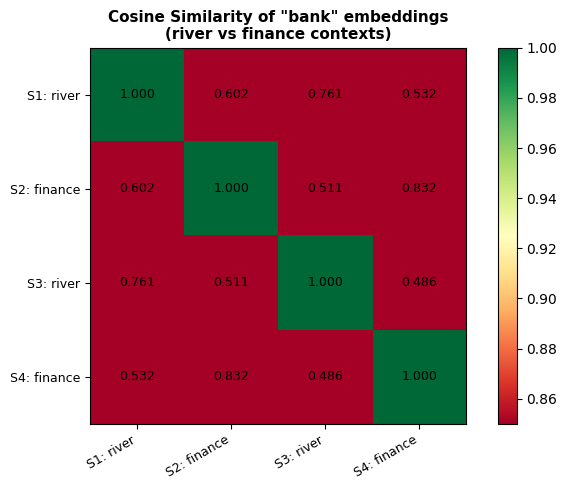

→ River contexts are more similar to each other than to finance contexts.
  Same word, same spelling — but BERT gives them different vectors based on context.


In [ ]:
#Context Sensitivity (Understanding)
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import matplotlib.pyplot as plt

# ── Demonstrate: same word, different context → different embedding ──
model_name = "bert-base-uncased"
tok   = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

sentences = [
    "I went to the river bank to fish.",
    "I deposited money at the bank.",
    "The bank of the river was muddy.",
    "The bank approved my loan application.",
]

target_word = "bank"

def get_word_embedding(sentence, word, tok, model):
    inputs = tok(sentence, return_tensors="pt")
    tokens = tok.convert_ids_to_tokens(inputs["input_ids"][0])
    word_idx = next(i for i, t in enumerate(tokens) if word in t)
    with torch.no_grad():
        out = model(**inputs).last_hidden_state[0, word_idx, :]
    return out.numpy(), tokens

print('=== Contextual Embeddings: "bank" in different sentences ===\n')
embeds = []
for s in sentences:
    emb, tokens = get_word_embedding(s, target_word, tok, model)
    embeds.append(emb)
    print(f"  [{tokens}]")
    print(f"  → Embedding norm: {np.linalg.norm(emb):.3f}\n")

# Cosine similarity between each pair
from sklearn.metrics.pairwise import cosine_similarity
emb_matrix = np.array(embeds)
sim = cosine_similarity(emb_matrix)

fig, ax = plt.subplots(figsize=(7, 5))
labels = [f"S{i+1}: {'river' if 'river' in s or 'fish' in s or 'muddy' in s else 'finance'}"
          for i, s in enumerate(sentences)]
im = ax.imshow(sim, cmap="RdYlGn", vmin=0.85, vmax=1.0)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
ax.set_title('Cosine Similarity of "bank" embeddings\n(river vs finance contexts)',
             fontweight="bold", fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{sim[i,j]:.3f}", ha="center", va="center", fontsize=9,
                color="black")
plt.tight_layout()
plt.show()

print("→ River contexts are more similar to each other than to finance contexts.")
print("  Same word, same spelling — but BERT gives them different vectors based on context.")

=== Autoregressive Generation (GPT-2) ===



model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'top_p', 'num_return_sequences', 'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt : The Transformer architecture works by
Output : The Transformer architecture works by a combination of the following:

The first two layers are placed on top of the first one. The fourth layer is placed on top of the first one.

The first layer is placed



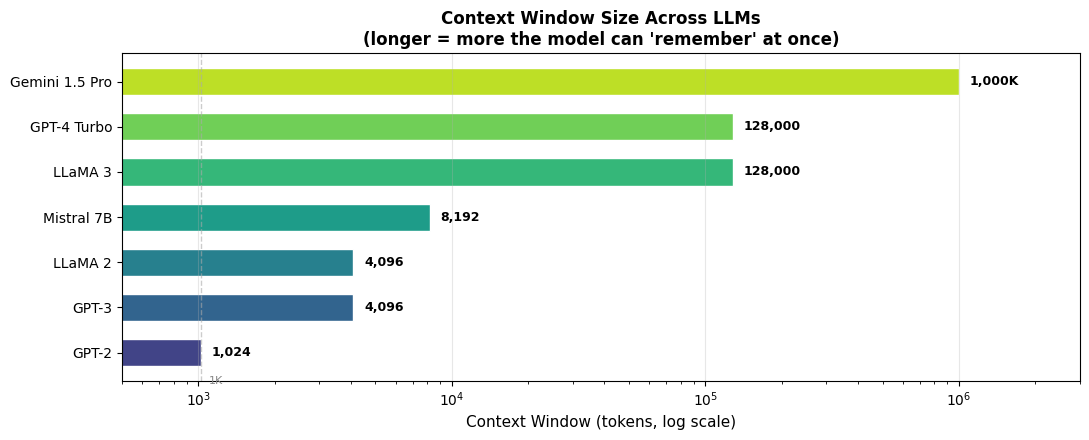

=== Attention Memory Cost: O(n²) ===
  seq_len=    128 → attention matrix =      0.1 MB
  seq_len=    512 → attention matrix =      1.0 MB
  seq_len=  1,024 → attention matrix =      4.0 MB
  seq_len=  4,096 → attention matrix =     64.0 MB
  seq_len=  8,192 → attention matrix =    256.0 MB
  seq_len= 32,768 → attention matrix =   4096.0 MB
  seq_len=128,000 → attention matrix =  62500.0 MB


In [ ]:
# Generation (Decoder) + Context Window
from transformers import pipeline, AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np

# ── Token-by-token generation: GPT-2 ──
print("=== Autoregressive Generation (GPT-2) ===\n")
generator = pipeline("text-generation", model="gpt2")
prompt = "The Transformer architecture works by"

result = generator(
    prompt,
    max_new_tokens=40,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    num_return_sequences=1
)[0]["generated_text"]

print(f"Prompt : {prompt}")
print(f"Output : {result}\n")

# ── Context window comparison across models ──
models_ctx = {
    "GPT-2":         1024,
    "GPT-3":         4096,
    "LLaMA 2":       4096,
    "Mistral 7B":    8192,
    "LLaMA 3":      128000,
    "GPT-4 Turbo":  128000,
    "Gemini 1.5 Pro": 1_000_000,
}

fig, ax = plt.subplots(figsize=(11, 4.5))
names  = list(models_ctx.keys())
values = list(models_ctx.values())
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(names)))

bars = ax.barh(names, values, color=colors, edgecolor="white", height=0.6)
ax.set_xscale("log")
ax.set_xlabel("Context Window (tokens, log scale)", fontsize=11)
ax.set_title("Context Window Size Across LLMs\n(longer = more the model can 'remember' at once)",
             fontsize=12, fontweight="bold")
ax.axvline(1024,   color="#aaa", lw=1, ls="--", alpha=0.6)
ax.text(1100, -0.7, "1K", fontsize=8, color="#888")

for bar, val in zip(bars, values):
    label = f"{val:,}" if val < 1_000_000 else f"{val//1000:,}K"
    ax.text(bar.get_width() * 1.1, bar.get_y() + bar.get_height()/2,
            label, va="center", fontsize=9, fontweight="bold")

ax.set_xlim(500, 3_000_000)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ── O(n²) attention cost demonstration ──
print("=== Attention Memory Cost: O(n²) ===")
lengths = [128, 512, 1024, 4096, 8192, 32768, 128000]
for n in lengths:
    cost = n * n * 4 / (1024**2)   # float32 bytes → MB
    print(f"  seq_len={n:>7,} → attention matrix = {cost:>8.1f} MB")

### Summary: The Full Picture

Raw Text<br>
│<br>
▼<br>
[Tokenizer] → token IDs (e.g. [101, 1996, 4937, 102])<br>
│<br>
▼<br>
[Embedding Table] → dense vectors (shape: seq_len × d_model)
│<br>
▼<br>
[+ Positional Encoding] → order-aware vectors<br>
│<br>
▼<br>
[Multi-Head Self-Attention] → contextual representations<br>
│ (each token now "knows about" every other token)<br>
▼<br>
[Feed-Forward Network] → richer per-token <br>transformation<br>
│<br>
▼ (repeat N layers)<br>
│<br>
├──[Encoder only] → Understanding: classification, NER, Q&A<br>
│<br>
└──[Decoder only] → Generation: next-token prediction, chat, code<br>


**The magic:** by stacking many layers of attention + feed-forward, the model builds increasingly abstract representations — from surface-level token patterns in early layers to high-level semantic concepts in later layers.

> **Explore further (Day 1):** [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/) ·
> [The Illustrated BERT](https://jalammar.github.io/illustrated-bert/) ·
> [Transformer Explainer — live simulation](https://poloclub.github.io/transformer-explainer/) ·
> [BertViz](https://github.com/jessevig/bertviz) · [Tiktokenizer](https://tiktokenizer.vercel.app/) ·
> [TensorFlow Embedding Projector](https://projector.tensorflow.org/) ·
> [Vaswani et al., 2017 — Attention Is All You Need](https://arxiv.org/abs/1706.03762)


---
# DAY 2 — Pre-training and Fine-tuning LLMs
---

### Transformers Are Language Models

All Transformer models (GPT, BERT, T5…) are trained as **language models** — trained on large amounts of raw text in a **self-supervised** fashion. No human labels needed.

**Two common self-supervised objectives:**

| Objective | Used By | How It Works |
|-----------|---------|-------------|
| **Causal Language Modeling (CLM)** | GPT-like | Predict the *next* word given previous words |
| **Masked Language Modeling (MLM)** | BERT-like | Predict a *masked* word from surrounding context |

The model builds a statistical understanding of language — but needs **fine-tuning** to be useful for specific tasks.

In [ ]:
# Visualizing the two pretraining objectives

sentence = ["The", "cat", "sat", "on", "the", "mat"]

# --- Causal LM (GPT-style): predict next token ---
print("=== Causal Language Modeling (CLM) ===")
for i in range(1, len(sentence)):
    context = " ".join(sentence[:i])
    target = sentence[i]
    print(f"  Input: [{context}]  →  Predict: '{target}'")

# --- Masked LM (BERT-style): predict masked token ---
print("\n=== Masked Language Modeling (MLM) ===")
import random
random.seed(7)
masked_idx = random.randint(1, len(sentence) - 2)
masked = sentence.copy()
masked[masked_idx] = "[MASK]"
print(f"  Input:  {' '.join(masked)}")
print(f"  Target: Predict '{sentence[masked_idx]}' at position {masked_idx}")

=== Causal Language Modeling (CLM) ===
  Input: [The]  →  Predict: 'cat'
  Input: [The cat]  →  Predict: 'sat'
  Input: [The cat sat]  →  Predict: 'on'
  Input: [The cat sat on]  →  Predict: 'the'
  Input: [The cat sat on the]  →  Predict: 'mat'

=== Masked Language Modeling (MLM) ===
  Input:  The cat sat [MASK] the mat
  Target: Predict 'on' at position 3


### Transfer Learning: Pretraining → Fine-tuning

**Pretraining** = training from scratch on massive raw text (weeks of compute, millions of examples).

**Fine-tuning** = taking a pretrained model and training it further on a small task-specific dataset (hours, thousands of examples).
<br><br>


```
Raw Text (unlabeled) Task Data (labeled)<br>
↓ ↓<br>
[ Pretrain on large corpus ] → [ Fine-tune on specific task ]<br>
↓ ↓<br>
General language model Task-specific model (classifier, NER, etc.)<br>
```




**Why fine-tune instead of train from scratch?**
- The pretrained model already understands grammar, facts, and context
- Fine-tuning needs far less data and compute
- Results are consistently better than training from scratch

> 💡 Always start from a pretrained model closest to your task and fine-tune it.

In [ ]:
from transformers import pipeline

# Pretrained model used out-of-the-box (general-purpose, zero-shot)
generic_generator = pipeline("text-generation", model="gpt2")
print("=== Pretrained (general) ===")
print(generic_generator("The best way to learn AI is", max_new_tokens=20, num_return_sequences=1)[0]["generated_text"])

# Fine-tuned model -- same underlying architecture family, specialized for sentiment classification
finetuned_classifier = pipeline("text-classification", model="distilbert-base-uncased-finetuned-sst-2-english")
print("\n=== Fine-tuned (task-specific: sentiment) ===")
for t in ["I love this course!", "This is confusing and hard."]:
    result = finetuned_classifier(t)[0]
    print(f"  '{t}' -> {result['label']} ({result['score']:.2f})")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Pretrained (general) ===
The best way to learn AI is to read about it. Take an interest in it and understand its concepts. When I first started out


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]


=== Fine-tuned (task-specific: sentiment) ===
  'I love this course!' -> POSITIVE (1.00)
  'This is confusing and hard.' -> NEGATIVE (1.00)


## Masked Language Modeling & Next-Token Prediction — the mechanics

We already saw *what* these objectives predict conceptually above. Now let's look at the actual
model outputs behind each one.

### Masked Language Modeling (MLM)
BERT-family models are pretrained by hiding a token and predicting it from context on **both** sides.

In [ ]:
from transformers import pipeline

fill_mask = pipeline("fill-mask", model="distilbert-base-uncased")
masked_sentence = "The capital of France is [MASK]."

predictions = fill_mask(masked_sentence)
for pred in predictions:
    score = pred["score"]
    sequence = pred["sequence"]
    print(f"{score:.3f}  ->  {sequence}")


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

0.143  ->  the capital of france is marseille.
0.090  ->  the capital of france is nantes.
0.088  ->  the capital of france is toulouse.
0.086  ->  the capital of france is paris.
0.077  ->  the capital of france is lyon.


### Next-Token Prediction
GPT-family models are pretrained with the opposite objective: given everything so far, predict only the
next token, strictly left to right, using masked (causal) self-attention so the model never sees the future.

In [ ]:
from transformers import AutoModelForCausalLM

gpt_tokenizer = AutoTokenizer.from_pretrained("gpt2")
gpt_model = AutoModelForCausalLM.from_pretrained("gpt2")
gpt_model.eval()

prompt = "The transformer architecture was introduced in a paper called"
gpt_inputs = gpt_tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    gpt_outputs = gpt_model(**gpt_inputs)

# logits: (batch, seq_len, vocab_size) -- a score for every possible next token, at every position.
# We only care about the prediction for the LAST position, i.e. what comes next.
next_token_logits = gpt_outputs.logits[0, -1, :]
next_token_probs = F.softmax(next_token_logits, dim=-1)
top_token_id = torch.argmax(next_token_probs).item()

print(f'Prompt: "{prompt}"')
print(f'Most likely next token: "{gpt_tokenizer.decode([top_token_id])}"')
print(f"Its probability:        {next_token_probs[top_token_id].item():.3f}")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Prompt: "The transformer architecture was introduced in a paper called"
Most likely next token: " ""
Its probability:        0.362


In [ ]:
# .generate() repeats the "predict next token, append it, repeat" loop automatically --
# exactly how GPT-style text generation works under the hood.
generated_ids = gpt_model.generate(
    **gpt_inputs,
    max_new_tokens=15,
    do_sample=False,       # greedy decoding: always pick the single most likely next token
    pad_token_id=gpt_tokenizer.eos_token_id,
)
print(gpt_tokenizer.decode(generated_ids[0], skip_special_tokens=True))


The transformer architecture was introduced in a paper called "The Power of the Electromagnetic Spectrum" by the University of California


## Transfer Learning with Domain Data

A pretrained model already knows grammar, world knowledge, and general reasoning -- fine-tuning doesn't
have to teach any of that again. Only a **small, labeled, domain-specific** dataset is needed. Below, we
run this recipe twice end-to-end: once for a classification task (DistilBERT), once for a
sequence-to-sequence task (T5-small).

## Fine-Tuning DistilBERT for Emotion Classification

Dataset: [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) -- short texts labeled with
one of six emotions (sadness, joy, love, anger, fear, surprise). This is a **many-to-one** problem: a full
sentence collapses into a single label.

In [ ]:
# Imports + checkpoint name (device comes from the single global `device` set up at the top of the notebook)
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel

MODEL_CKPT = "distilbert-base-uncased"   # single source of truth for the checkpoint name
print(f"Device: {device}")


Device: mps


In [ ]:
# Load Dataset + EDA Setup
emotion = load_dataset("dair-ai/emotion")

emotion.set_format(type="pandas")
df = emotion["train"][:]

classes  = emotion["train"].features["label"].names   # ['sadness','joy','love','anger','fear','surprise']
id2label = {i: c for i, c in enumerate(classes)}
label2id = {c: i for i, c in enumerate(classes)}
df["label_name"] = df["label"].map(id2label)

print(f"Splits : {list(emotion.keys())}")
print(f"Train  : {len(emotion['train']):,} | Val: {len(emotion['validation']):,} | Test: {len(emotion['test']):,}")
print(f"Classes: {classes}")
df.head()


Splits : ['train', 'validation', 'test']
Train  : 16,000 | Val: 2,000 | Test: 2,000
Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


/var/folders/s5/5fzxfr3d60ggtgm1bdjr61940000gn/T/ipykernel_79313/1138300162.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(grouped, labels=classes, vert=True)


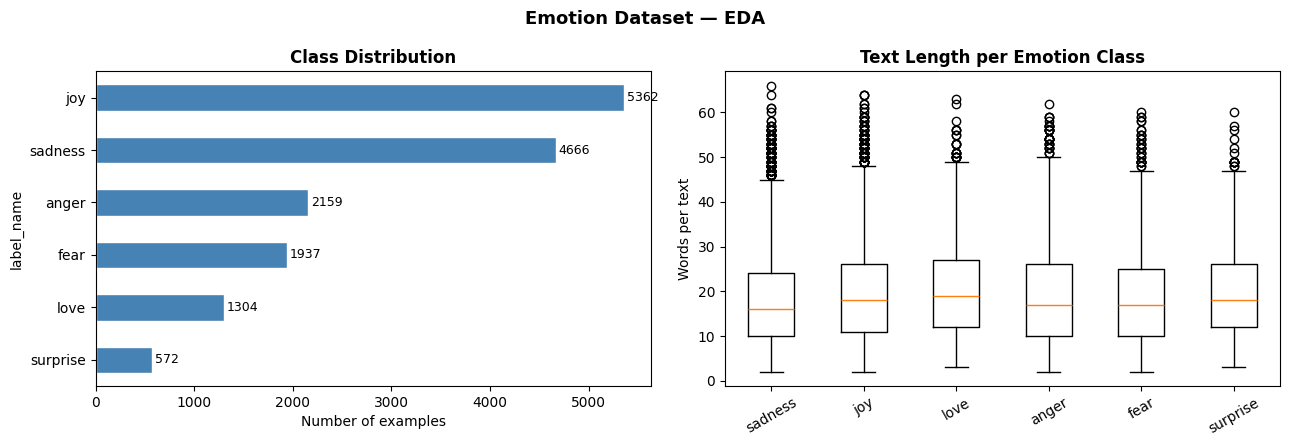


Max text length : 66 words
Mean text length: 19.2 words


In [ ]:
# EDA: Class Balance + Text Length
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

label_counts = df["label_name"].value_counts(ascending=True)
label_counts.plot.barh(ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_xlabel("Number of examples")
for i, v in enumerate(label_counts):
    axes[0].text(v + 30, i, str(v), va="center", fontsize=9)

df["words"] = df["text"].str.split().apply(len)
grouped = [df[df["label_name"] == c]["words"].values for c in classes]
axes[1].boxplot(grouped, labels=classes, vert=True)
axes[1].set_title("Text Length per Emotion Class", fontweight="bold")
axes[1].set_ylabel("Words per text")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Emotion Dataset — EDA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nMax text length : {df['words'].max()} words")
print(f"Mean text length: {df['words'].mean():.1f} words")


In [ ]:
# Load Tokenizer + Plain (headless) Model -- to inspect raw hidden states before attaching a classifier
clf_tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)
plain_model = AutoModel.from_pretrained(MODEL_CKPT).to(device)
plain_model.eval()

print(f"Tokenizer vocab size : {clf_tokenizer.vocab_size:,}")
print(f"Model hidden size    : {plain_model.config.hidden_size}")
print(f"Model on             : {next(plain_model.parameters()).device}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tokenizer vocab size : 30,522
Model hidden size    : 768
Model on             : mps:0


In [ ]:
# Tokenize Dataset
emotion.reset_format()   # back to native Arrow format after the pandas EDA above

def tokenize(batch):
    return clf_tokenizer(batch["text"], padding=True, truncation=True)

emotions_encoded = emotion.map(tokenize, batched=True, batch_size=None)

# Drop the raw text column (the model only needs input_ids/attention_mask) and rename
# "label" -> "labels", which is the exact column name the Trainer expects.
emotions_encoded = emotions_encoded.remove_columns(["text"])
emotions_encoded = emotions_encoded.rename_column("label", "labels")

print(emotions_encoded)
sample = emotions_encoded["train"][0]
print(f"\nSample keys      : {list(sample.keys())}")
print(f"input_ids length : {len(sample['input_ids'])}")
print(f"label            : {sample['labels']}  -> {id2label[sample['labels']]}")


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

Sample keys      : ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
input_ids length : 87
label            : 0  -> sadness


In [ ]:
# Inspect Plain Model Hidden States (no classification head yet)
sample_texts = ["I love learning about transformers!", "This is the worst day ever."]
sample_inputs = clf_tokenizer(sample_texts, return_tensors="pt", padding=True, truncation=True)
sample_inputs = {k: v.to(device) for k, v in sample_inputs.items()}

with torch.no_grad():
    sample_outputs = plain_model(**sample_inputs)

# last_hidden_state: (batch, seq_len, hidden_dim) -- one 768-dim vector per token, per example.
hs = sample_outputs.last_hidden_state
print(f"last_hidden_state shape : {hs.shape}")
print(f"  batch size            : {hs.shape[0]}  (2 sentences)")
print(f"  sequence length       : {hs.shape[1]}  (padded token count)")
print(f"  hidden dimension      : {hs.shape[2]}  (768 for DistilBERT)")

# The [CLS] token (position 0) aggregates the whole sentence -- this is exactly what a
# classification head is trained to read.
cls_vectors = hs[:, 0, :]
print(f"\n[CLS] vector shape      : {cls_vectors.shape}  <- input to the classification head")


last_hidden_state shape : torch.Size([2, 9, 768])
  batch size            : 2  (2 sentences)
  sequence length       : 9  (padded token count)
  hidden dimension      : 768  (768 for DistilBERT)

[CLS] vector shape      : torch.Size([2, 768])  <- input to the classification head


In [ ]:
# Load Classification Model -- SAME pretrained weights, plus a fresh randomly-initialized
# classification head (num_labels=6, one per emotion). This is the "small task-specific head"
# step from the Day 2 slides.
from transformers import AutoModelForSequenceClassification

clf_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=len(classes),
    id2label=id2label,
    label2id=label2id,
).to(device)

total_params     = sum(p.numel() for p in clf_model.parameters())
trainable_params = sum(p.numel() for p in clf_model.parameters() if p.requires_grad)

print(f"Checkpoint        : {MODEL_CKPT}")
print(f"Labels            : {classes}")
print(f"Total parameters  : {total_params:,}")
print(f"Trainable params  : {trainable_params:,}")
print(f"Model on          : {next(clf_model.parameters()).device}")
# Loading here will print a warning that the classifier weights are newly initialized --
# that is expected: it is exactly the "fresh head" fine-tuning is about to train.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Checkpoint        : distilbert-base-uncased
Labels            : ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Total parameters  : 66,958,086
Trainable params  : 66,958,086
Model on          : mps:0


In [ ]:
# Training Arguments
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir             = "distilbert-finetuned-emotion",
    num_train_epochs       = 2,
    learning_rate          = 2e-5,    # small LR: nudge pretrained weights, don't overwrite them
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    weight_decay           = 0.01,
    eval_strategy          = "epoch",
    save_strategy          = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model  = "f1",
    fp16                   = torch.cuda.is_available(),  # half-precision only helps on GPU
    report_to              = "none",
    disable_tqdm           = False,
    logging_steps          = 50,
)

print("Training config:")
print(f"  Epochs        : {training_args.num_train_epochs}")
print(f"  Batch size    : {training_args.per_device_train_batch_size}")
print(f"  Learning rate : {training_args.learning_rate}")
print(f"  Device        : {device}")


Training config:
  Epochs        : 2
  Batch size    : 16
  Learning rate : 2e-05
  Device        : mps


In [ ]:
# Metrics + Trainer
from sklearn.metrics import accuracy_score, f1_score
from transformers import Trainer

def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)                    # highest logit = predicted class
    f1  = f1_score(labels, preds, average="weighted")       # weighted: accounts for class imbalance
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

trainer = Trainer(
    model           = clf_model,
    args            = training_args,
    compute_metrics = compute_metrics,
    train_dataset   = emotions_encoded["train"],
    eval_dataset    = emotions_encoded["validation"],
    processing_class = clf_tokenizer,
)
print("Trainer ready.")


Trainer ready.


In [ ]:
# Baseline Eval + Fine-tuning
print("=" * 50)
print("Baseline (before fine-tuning) -- random head:")
print("=" * 50)
pre_metrics = trainer.evaluate()
print(f"  Accuracy : {pre_metrics['eval_accuracy']:.3f}  (chance ~= 0.167 for 6 classes)")
print(f"  F1       : {pre_metrics['eval_f1']:.3f}")

print("\n" + "=" * 50)
print("Fine-tuning...")
print("=" * 50)
trainer.train()


Baseline (before fine-tuning) -- random head:


/Users/vinaykumar/visualcode/Transformers_v/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,1.791466,0,0.137000,0.034377


  Accuracy : 0.137  (chance ~= 0.167 for 6 classes)
  F1       : 0.034

Fine-tuning...


/Users/vinaykumar/visualcode/Transformers_v/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.214097,0.195720,0.923000,0.923863
2,0.132188,0.147756,0.938500,0.938342


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/vinaykumar/visualcode/Transformers_v/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2000, training_loss=0.3106910245418549, metrics={'train_runtime': 535.7573, 'train_samples_per_second': 59.729, 'train_steps_per_second': 3.733, 'total_flos': 720342861696000.0, 'train_loss': 0.3106910245418549, 'epoch': 2.0})

Test Set Evaluation


/Users/vinaykumar/visualcode/Transformers_v/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Test metrics: {'test_loss': 0.16456368565559387, 'test_model_preparation_time': 0.0011, 'test_accuracy': 0.9275, 'test_f1': 0.927159323178436, 'test_runtime': 4.8898, 'test_samples_per_second': 409.018, 'test_steps_per_second': 25.564}

Per-class breakdown:
              precision    recall  f1-score   support

     sadness       0.96      0.97      0.96       581
         joy       0.95      0.95      0.95       695
        love       0.82      0.86      0.84       159
       anger       0.93      0.92      0.92       275
        fear       0.89      0.89      0.89       224
    surprise       0.79      0.68      0.73        66

    accuracy                           0.93      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.93      0.93      0.93      2000



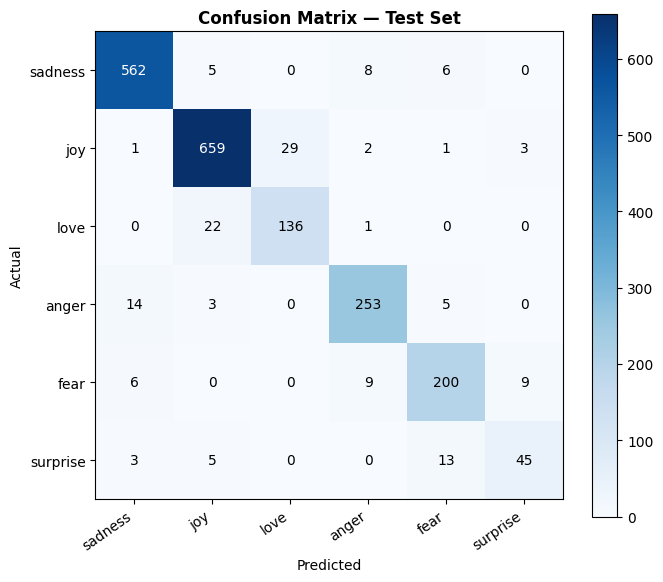

In [ ]:
# Test Evaluation + Classification Report + Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix

print("=" * 50)
print("Test Set Evaluation")
print("=" * 50)

preds_output = trainer.predict(emotions_encoded["test"])
print("Test metrics:", preds_output.metrics)

y_preds = np.argmax(preds_output.predictions, axis=1)
y_true  = np.array(emotions_encoded["test"]["labels"])

print("\nPer-class breakdown:")
print(classification_report(y_true, y_preds, target_names=classes))

cm = confusion_matrix(y_true, y_preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=35, ha="right")
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Test Set", fontweight="bold")
plt.colorbar(im, ax=ax)
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                fontsize=10, color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()


In [ ]:
# Save Model
SAVE_DIR = "emotion_model"
trainer.save_model(SAVE_DIR)
clf_tokenizer.save_pretrained(SAVE_DIR)

import os
print(f"Model + tokenizer saved to: {SAVE_DIR}/")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f"{SAVE_DIR}/{f}") / 1024
    print(f"  {f:40s}  {size:>8.1f} KB")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model + tokenizer saved to: emotion_model/
  config.json                                    0.9 KB
  model.safetensors                         261567.3 KB
  tokenizer.json                               695.0 KB
  tokenizer_config.json                          0.3 KB
  training_args.bin                              5.1 KB


In [ ]:
# Reload + Inference -- exactly as a downstream application would, no dependency on any earlier variable
from transformers import AutoTokenizer, AutoModelForSequenceClassification

inf_tokenizer = AutoTokenizer.from_pretrained("emotion_model")
inf_model     = AutoModelForSequenceClassification.from_pretrained("emotion_model")
inf_model.eval()

def predict_emotion(text, top_k=3):
    inputs = inf_tokenizer(text, return_tensors="pt", truncation=True)
    with torch.no_grad():
        logits = inf_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)[0]
    top   = probs.argsort(descending=True)[:top_k]
    print(f'\nText: "{text[:80]}..."' if len(text) > 80 else f'\nText: "{text}"')
    for rank, idx in enumerate(top, 1):
        label = inf_model.config.id2label[idx.item()]
        prob  = probs[idx].item()
        bar   = "█" * int(prob * 30)
        print(f"  {rank}. {label:10s} {bar} {prob:.3f}")
    return inf_model.config.id2label[probs.argmax().item()]

sample = ("I was getting ready for the weekend and planned to go hiking with my friend, "
          "but he cancelled at the last minute and I ended up feeling pretty lonely.")
result = predict_emotion(sample)
print(f"\nFinal prediction: {result}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Text: "I was getting ready for the weekend and planned to go hiking with my friend, but..."
  1. sadness    █████████████████████████████ 0.997
  2. love        0.001
  3. fear        0.001

Final prediction: sadness


In [ ]:
# Reload + Inference -- exactly as a downstream application would, no dependency on any earlier variable
from transformers import AutoTokenizer, AutoModelForSequenceClassification

inf_tokenizer = AutoTokenizer.from_pretrained("emotion_model")
inf_model     = AutoModelForSequenceClassification.from_pretrained("emotion_model")
inf_model.eval()

def predict_emotion(text, top_k=3):
    inputs = inf_tokenizer(text, return_tensors="pt", truncation=True)
    with torch.no_grad():
        logits = inf_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)[0]
    top   = probs.argsort(descending=True)[:top_k]
    print(f'\nText: "{text[:80]}..."' if len(text) > 80 else f'\nText: "{text}"')
    for rank, idx in enumerate(top, 1):
        label = inf_model.config.id2label[idx.item()]
        prob  = probs[idx].item()
        bar   = "█" * int(prob * 30)
        print(f"  {rank}. {label:10s} {bar} {prob:.3f}")
    return inf_model.config.id2label[probs.argmax().item()]

sample = ("I feel very sad after interacting with him.")
result = predict_emotion(sample)
print(f"\nFinal prediction: {result}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Text: "I feel very sad after interacting with him."
  1. sadness    █████████████████████████████ 0.997
  2. love        0.001
  3. joy         0.001

Final prediction: sadness


In [ ]:
# Reload + Inference -- exactly as a downstream application would, no dependency on any earlier variable
from transformers import AutoTokenizer, AutoModelForSequenceClassification

inf_tokenizer = AutoTokenizer.from_pretrained("emotion_model")
inf_model     = AutoModelForSequenceClassification.from_pretrained("emotion_model")
inf_model.eval()

def predict_emotion(text, top_k=3):
    inputs = inf_tokenizer(text, return_tensors="pt", truncation=True)
    with torch.no_grad():
        logits = inf_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)[0]
    top   = probs.argsort(descending=True)[:top_k]
    print(f'\nText: "{text[:80]}..."' if len(text) > 80 else f'\nText: "{text}"')
    for rank, idx in enumerate(top, 1):
        label = inf_model.config.id2label[idx.item()]
        prob  = probs[idx].item()
        bar   = "█" * int(prob * 30)
        print(f"  {rank}. {label:10s} {bar} {prob:.3f}")
    return inf_model.config.id2label[probs.argmax().item()]

sample = ("I feel delighted after learning today.")
result = predict_emotion(sample)
print(f"\nFinal prediction: {result}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Text: "I feel delighted after learning today."
  1. joy        █████████████████████████████ 0.998
  2. love        0.001
  3. surprise    0.001

Final prediction: joy


## Fine-Tuning T5-small for Dialogue Summarization

T5 treats every task as text-to-text: input text in, output text out, always. Dataset:
[`samsum`](https://huggingface.co/datasets/samsum) -- short multi-turn dialogues paired with a
human-written one- or two-sentence summary. This is an **asynchronous many-to-many** problem: input and
output lengths are unrelated to each other.

In [ ]:
from datasets import load_dataset

samsum = load_dataset("knkarthick/samsum")
print(samsum)
print("\nExample dialogue:")
print(samsum["train"][0]["dialogue"])
print("\nExample summary:")
print(samsum["train"][0]["summary"])


README.md:   0%|          | 0.00/4.36k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/9.26M [00:00<?, ?B/s]

validation.csv:   0%|          | 0.00/504k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/522k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14731 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

Example dialogue:
Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

Example summary:
Amanda baked cookies and will bring Jerry some tomorrow.


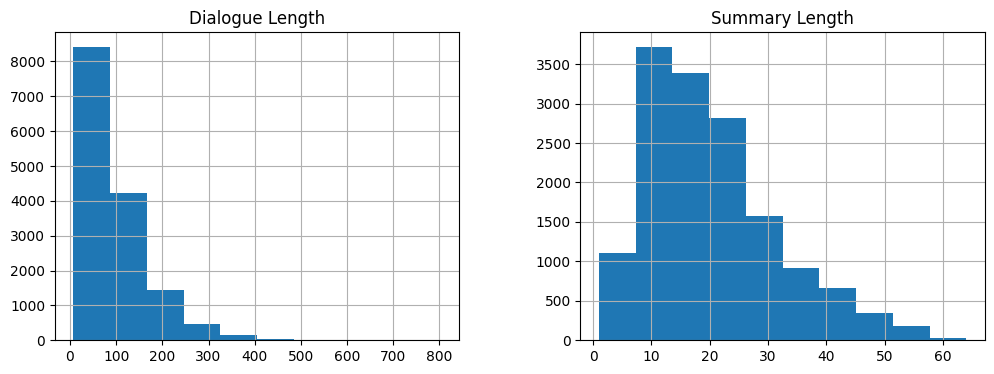

In [ ]:
# EDA: how long are the dialogues vs. their summaries? T5 needs a max_length set for both sides below.
dialogue_len = [len(x["dialogue"].split()) for x in samsum["train"]]
summary_len  = [len(x["summary"].split())  for x in samsum["train"]]

length_df = pd.DataFrame({"Dialogue Length": dialogue_len, "Summary Length": summary_len})
length_df.hist(figsize=(12, 4))
plt.show()


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

t5_checkpoint = "t5-small"
t5_tokenizer = AutoTokenizer.from_pretrained(t5_checkpoint)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(t5_checkpoint).to(device)

# T5 needs an explicit task PREFIX prepended to every input -- this is how one shared model
# knows which text-to-text task to perform (summarization, translation, etc.).
TASK_PREFIX = "summarize: "

def get_feature(batch):
    inputs_with_prefix = [TASK_PREFIX + dialogue for dialogue in batch["dialogue"]]
    # text_target=... tells the tokenizer these are the TARGET summaries, applying whatever
    # decoder-side tokenization conventions T5 expects on the label side.
    encodings = t5_tokenizer(
        inputs_with_prefix,
        text_target=batch["summary"],
        max_length=512,
        truncation=True,
    )
    return {
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"],
        "labels": encodings["labels"],
    }

samsum_pt = samsum.map(get_feature, batched=True)
samsum_pt.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
print(samsum_pt)


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  242MB            

...

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 819
    })
})


In [ ]:
def summarize_with_t5(dialogue_text, model_to_use):
    """Run T5 in inference mode on one piece of text and return its generated summary."""
    input_text = TASK_PREFIX + dialogue_text
    input_ids = t5_tokenizer(input_text, return_tensors="pt", truncation=True, max_length=512).input_ids.to(device)
    output_ids = model_to_use.generate(input_ids, max_new_tokens=60)
    return t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)

# Check the UN-fine-tuned, purely pretrained T5-small BEFORE we touch its weights.
sample_dialogue = samsum["validation"][0]["dialogue"]
print("BEFORE fine-tuning:")
print(summarize_with_t5(sample_dialogue, t5_model))
print("\nReference summary:")
print(samsum["validation"][0]["summary"])


BEFORE fine-tuning:
a dog is a tough issue, like having a baby. he's ready to take it home right away. he's a great motorhead fan.

Reference summary:
A will go to the animal shelter tomorrow to get a puppy for her son. They already visited the shelter last Monday and the son chose the puppy. 


In [ ]:
from rouge_score import rouge_scorer
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer

data_collator = DataCollatorForSeq2Seq(t5_tokenizer, model=t5_model)

rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def compute_seq2seq_metrics(eval_pred):
    predictions, labels = eval_pred

    # Both predictions AND labels can contain the -100 padding sentinel when generated
    # sequences have different lengths across an eval batch -- replace both before decoding.
    predictions = np.where(predictions != -100, predictions, t5_tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, t5_tokenizer.pad_token_id)

    decoded_preds  = t5_tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = t5_tokenizer.batch_decode(labels, skip_special_tokens=True)

    scores = {"rouge1": [], "rouge2": [], "rougeL": []}
    for pred, ref in zip(decoded_preds, decoded_labels):
        s = rouge.score(ref, pred)
        for k in scores:
            scores[k].append(s[k].fmeasure)
    return {k: round(float(np.mean(v)), 4) for k, v in scores.items()}

# import evaluate
# from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer

# # DataCollatorForSeq2Seq pads inputs AND labels correctly for an encoder-decoder model, and masks
# # that label padding out of the loss calculation.
# data_collator = DataCollatorForSeq2Seq(t5_tokenizer, model=t5_model)

# rouge = evaluate.load("rouge")

# def compute_seq2seq_metrics(eval_pred):
#     predictions, labels = eval_pred
#     # Replace the -100 padding sentinel the collator uses for labels with the real pad token
#     # id before decoding, or the tokenizer will choke trying to decode -100.
#     labels = np.where(labels != -100, labels, t5_tokenizer.pad_token_id)
#     decoded_preds  = t5_tokenizer.batch_decode(predictions, skip_special_tokens=True)
#     decoded_labels = t5_tokenizer.batch_decode(labels, skip_special_tokens=True)
#     result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
#     return {k: round(v, 4) for k, v in result.items()}

seq2seq_training_args = Seq2SeqTrainingArguments(
    output_dir="t5-small-samsum-finetuned",
    num_train_epochs=1,
    warmup_steps=500,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=200,
    save_steps=int(1e6),
    gradient_accumulation_steps=16,
    predict_with_generate=True,
    generation_max_length=60,     # match the max_new_tokens we use elsewhere for T5 summaries
    fp16=torch.cuda.is_available(),
    report_to="none",
)

# seq2seq_training_args = Seq2SeqTrainingArguments(
#     output_dir="t5-small-samsum-finetuned",
#     num_train_epochs=1,
#     warmup_steps=500,
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     weight_decay=0.01,
#     logging_steps=10,
#     eval_strategy="steps",
#     eval_steps=200,
#     save_steps=int(1e6),          # effectively disables mid-training checkpoint saving for this demo
#     gradient_accumulation_steps=16,
#     predict_with_generate=True,   # evaluate using actually-generated text, not just next-token loss
#     fp16=torch.cuda.is_available(),
#     report_to="none",
# )

seq2seq_trainer = Seq2SeqTrainer(
    model=t5_model,
    args=seq2seq_training_args,
    processing_class=t5_tokenizer,
    data_collator=data_collator,
    train_dataset=samsum_pt["train"],
    eval_dataset=samsum_pt["validation"],
    compute_metrics=compute_seq2seq_metrics,
)

# Fine-tune: specializes T5-small's general text-to-text ability toward dialogue summarization.
seq2seq_trainer.train()


Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
200,33.509857,1.931620,0.388500,0.163300,0.320100
231,34.228842,1.914683,0.394700,0.168900,0.326100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=231, training_loss=34.82865965624392, metrics={'train_runtime': 1082.7093, 'train_samples_per_second': 13.606, 'train_steps_per_second': 0.213, 'total_flos': 1042041467240448.0, 'train_loss': 34.82865965624392, 'epoch': 1.0})

In [ ]:
# Test-set ROUGE, for a quantitative counterpart to the qualitative before/after comparison below.
test_metrics = seq2seq_trainer.evaluate(samsum_pt["test"])
print("Test set ROUGE:", test_metrics)


/Users/vinaykumar/visualcode/Transformers_v/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Rouge1,Rouge2,Rougel
34.228842,1.921198,231,0.384800,0.152100,0.317100


Test set ROUGE: {'eval_loss': 1.9211980104446411, 'eval_rouge1': 0.3848, 'eval_rouge2': 0.1521, 'eval_rougeL': 0.3171}


In [ ]:
sample_dialogue

"A: Hi Tom, are you busy tomorrow’s afternoon?\nB: I’m pretty sure I am. What’s up?\nA: Can you go with me to the animal shelter?.\nB: What do you want to do?\nA: I want to get a puppy for my son.\nB: That will make him so happy.\nA: Yeah, we’ve discussed it many times. I think he’s ready now.\nB: That’s good. Raising a dog is a tough issue. Like having a baby ;-) \nA: I'll get him one of those little dogs.\nB: One that won't grow up too big;-)\nA: And eat too much;-))\nB: Do you know which one he would like?\nA: Oh, yes, I took him there last Monday. He showed me one that he really liked.\nB: I bet you had to drag him away.\nA: He wanted to take it home right away ;-).\nB: I wonder what he'll name it.\nA: He said he’d name it after his dead hamster – Lemmy  - he's  a great Motorhead fan :-)))"

In [ ]:
# Compare the SAME example again, now using the fine-tuned model, against the pretrained-only
# output captured earlier -- the clearest possible demonstration of what fine-tuning changed.
print("AFTER fine-tuning:")
print(summarize_with_t5(sample_dialogue, t5_model))
print("\nReference summary:")
print(samsum["validation"][0]["summary"])


[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AFTER fine-tuning:
A wants to get a puppy for his son. He will be able to take him home right away.

Reference summary:
A will go to the animal shelter tomorrow to get a puppy for her son. They already visited the shelter last Monday and the son chose the puppy. 


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Reload exactly as a downstream app would, straight from the saved checkpoint
saved_tokenizer = AutoTokenizer.from_pretrained("t5_small_samsum_model")
saved_model = AutoModelForSeq2SeqLM.from_pretrained("t5_small_samsum_model").to(device)

custom_dialogue = """
A will go to the animal shelter tomorrow to get a puppy for her son. They already visited the shelter last Monday and the son chose the puppy.
"""

# Reuses the summarize_with_t5() helper defined earlier in the notebook -- no pipeline() needed.
print(summarize_with_t5(custom_dialogue, saved_model))
# T5 needs the same "summarize: " prefix at inference time as it saw during fine-tuning.
# print(summarizer(TASK_PREFIX + custom_dialogue, max_length=600)[0]["summary_text"])

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A will go to the animal shelter tomorrow to get a puppy for her son.


## Recap

- **Day 1** — what transformers can do, transformer history, the encoder/decoder architecture in full
  (BERT / GPT / T5), attention from scratch (toy and real), tokenization, embeddings, positional encoding,
  and the practical implications of all of it put together.
- **Day 2** — pretraining vs. fine-tuning as a concept, the MLM and next-token objectives that make
  pretraining possible, and two complete fine-tuning runs: DistilBERT for emotion classification, T5-small
  for dialogue summarization — each with a clear before/after comparison and quantitative evaluation.

The same recipe used in both fine-tuning runs (load a pretrained checkpoint → tokenize a small labeled
dataset → train with a small learning rate → evaluate) is exactly the recipe used to fine-tune any
transformer model on any domain-specific dataset.

---

### Resources & interactive simulations

- [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/) — Jay Alammar
- [The Illustrated BERT](https://jalammar.github.io/illustrated-bert/) — Jay Alammar
- [Transformer Explainer](https://poloclub.github.io/transformer-explainer/) — live in-browser transformer simulation (Georgia Tech / Poloclub)
- [bbycroft.net/llm](https://bbycroft.net/llm) — 3D visualization of LLM internals
- [Tiktokenizer](https://tiktokenizer.vercel.app/) — live tokenization playground
- [TensorFlow Embedding Projector](https://projector.tensorflow.org/)
- [BertViz](https://github.com/jessevig/bertviz) — interactive attention-head visualization library
- [Distill.pub — Attention and Augmented RNNs](https://distill.pub/2016/augmented-rnns/)
- [Vaswani et al., 2017 — Attention Is All You Need](https://arxiv.org/abs/1706.03762)
- [Howard & Ruder, 2018 — ULMFiT](https://arxiv.org/abs/1801.06146)
- [dair-ai/emotion dataset card](https://huggingface.co/datasets/dair-ai/emotion)
- [samsum dataset card](https://huggingface.co/datasets/samsum)
